Dataset loaded successfully!

First 5 rows:
   Area  Bedrooms  Bathrooms  Age       Location     Price
0  1922         3          4    5     Vijayawada   7471000
1  2920         4          4    8      Bengaluru  19180000
2  2318         4          4   15        Chennai  12780000
3  1325         3          3    3  Visakhapatnam   6736000
4  1116         2          2    2      Hyderabad   5815000

Shape:
(500, 6)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       500 non-null    int64
 1   Bedrooms   500 non-null    int64
 2   Bathrooms  500 non-null    int64
 3   Age        500 non-null    int64
 4   Location   500 non-null    str  
 5   Price      500 non-null    int64
dtypes: int64(5), str(1)
memory usage: 23.6 KB

Data Types:
Area         int64
Bedrooms     int64
Bathrooms    int64
Age          int64
Location       str
Price      

C:\Users\saniy\AppData\Local\Temp\ipykernel_16540\2476979811.py:40: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(
C:\Users\saniy\AppData\Local\Temp\ipykernel_16540\2476979811.py:78: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-s

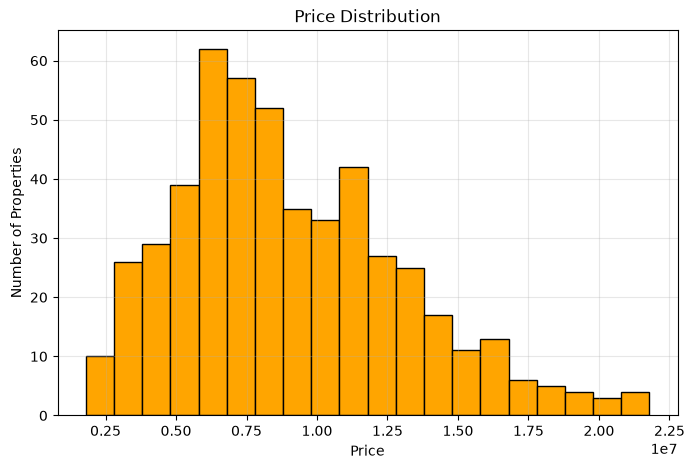

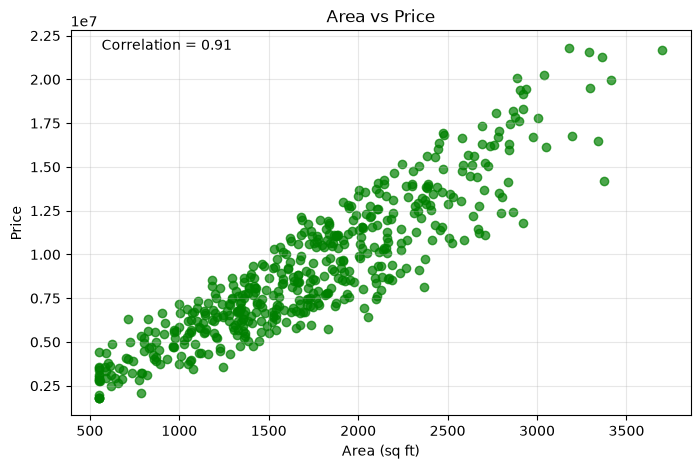

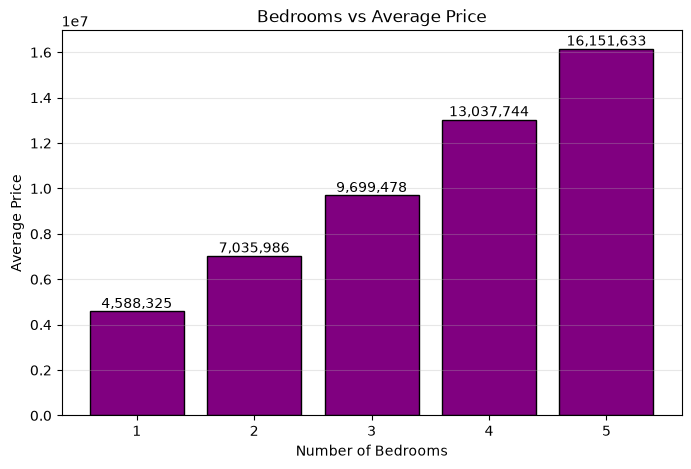

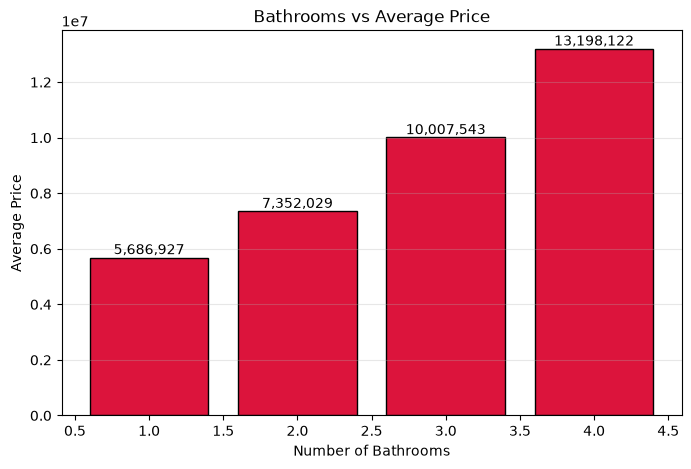

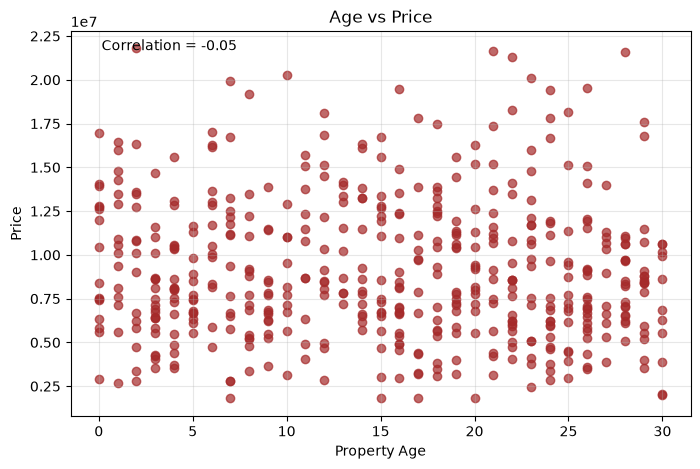

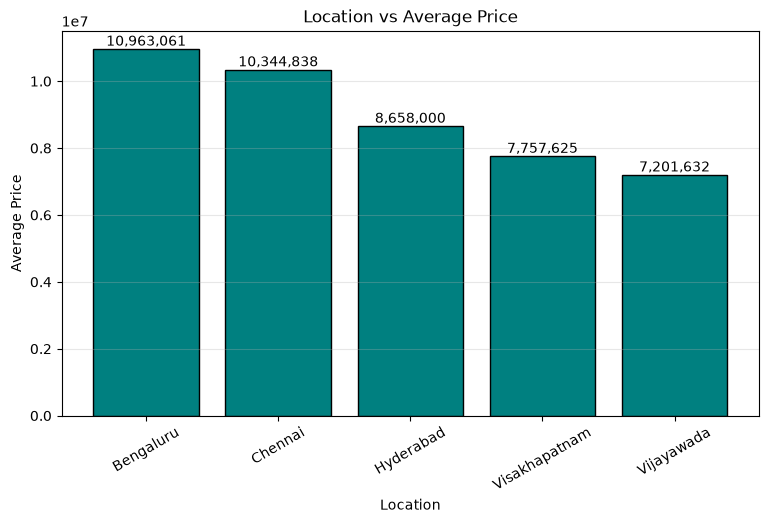

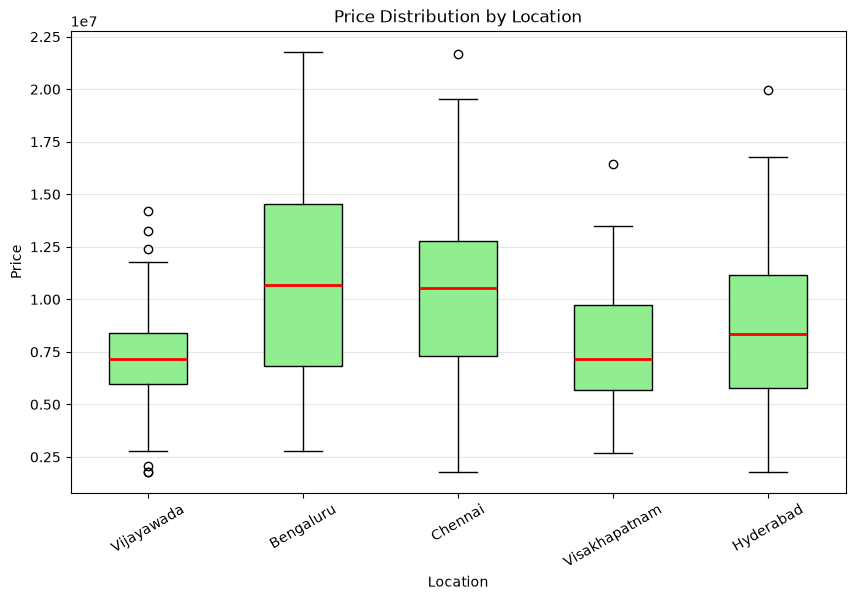

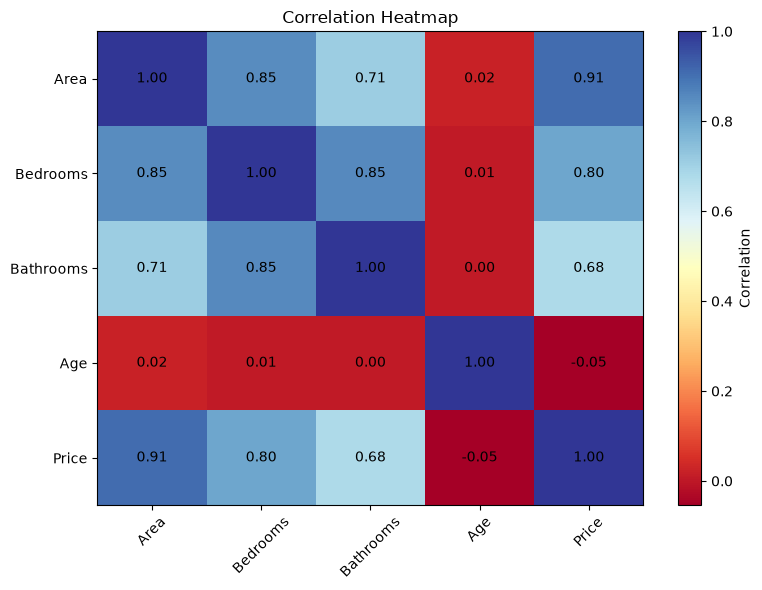


MOST EXPENSIVE PROPERTY
Area              3176
Bedrooms             5
Bathrooms            4
Age                  2
Location     Bengaluru
Price         21791000
Name: 197, dtype: object

CHEAPEST PROPERTY
Area                550
Bedrooms              1
Bathrooms             1
Age                   7
Location     Vijayawada
Price           1800000
Name: 180, dtype: object


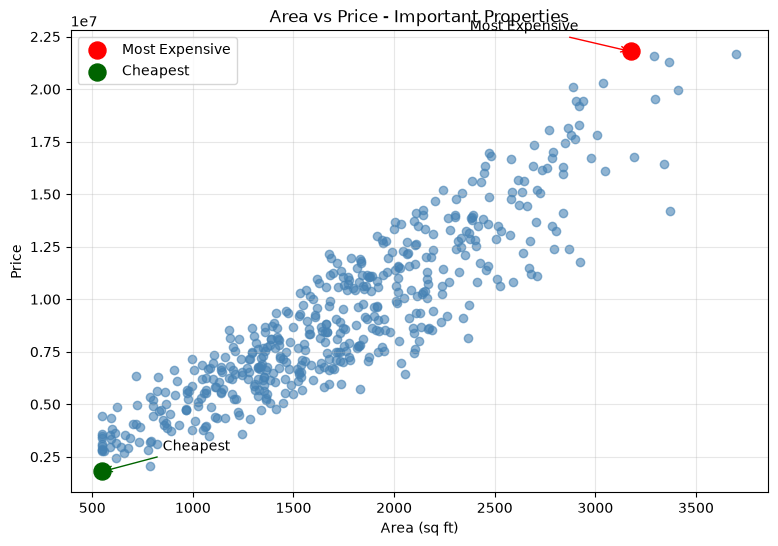

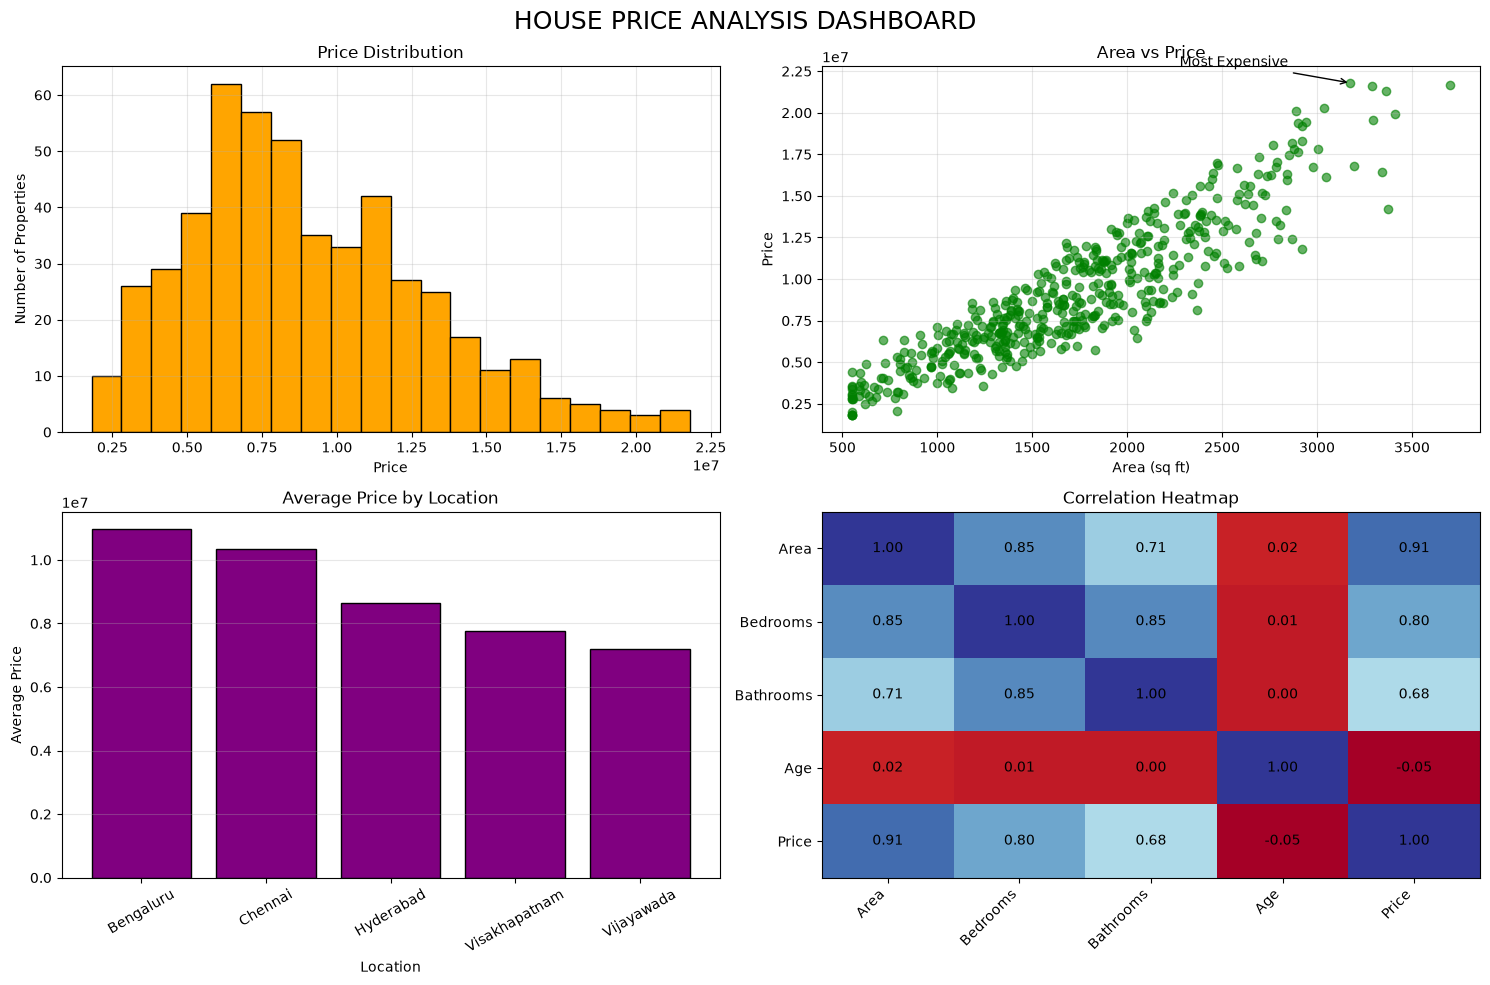


BUSINESS / TECHNICAL INSIGHTS

1. Area and Price have a correlation of 0.91.

2. Age and Price have a correlation of -0.05.

3. Bengaluru has the highest average property price.

4. Vijayawada has the lowest average property price.

5. Properties with 5 bedrooms have the highest average price.

6. Properties with 4 bathrooms have the highest average price.

7. The most expensive property costs 21,791,000.

8. The cheapest property costs 1,800,000.

FINAL DATASET CHECK
Final Shape: (500, 6)

Remaining Missing Values:
Area         0
Bedrooms     0
Bathrooms    0
Age          0
Location     0
Price        0
dtype: int64

Remaining Duplicate Records:
0

Analysis completed successfully!


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

file_name = "house_prices_500.csv"

if not os.path.exists(file_name):
    raise FileNotFoundError(
        f"'{file_name}' was not found.\n"
        f"Current working directory: {os.getcwd()}\n\n"
        f"Please place '{file_name}' in this folder or provide the full path."
    )

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values Before:")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(
    include="number"
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)

print("\nStatistical Summary:")
print(df.describe())

print("\nAverage Price:")
print(df["Price"].mean())

print("\nMedian Price:")
print(df["Price"].median())

print("\nMinimum Price:")
print(df["Price"].min())

print("\nMaximum Price:")
print(df["Price"].max())

numerical_columns = df.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

plt.figure(figsize=(8, 5))

plt.hist(
    df["Price"],
    bins=20,
    color="orange",
    edgecolor="black"
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.grid(True, alpha=0.3)

plt.show()

area_corr = df["Area"].corr(df["Price"])

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["Price"],
    color="green",
    alpha=0.7
)

plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

plt.text(
    0.05,
    0.95,
    f"Correlation = {area_corr:.2f}",
    transform=plt.gca().transAxes
)

plt.show()

bedroom_avg = df.groupby(
    "Bedrooms"
)["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    bedroom_avg.index,
    bedroom_avg.values,
    color="purple",
    edgecolor="black"
)

plt.title("Bedrooms vs Average Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.grid(True, axis="y", alpha=0.3)

for x, y in zip(
    bedroom_avg.index,
    bedroom_avg.values
):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.show()

bathroom_avg = df.groupby(
    "Bathrooms"
)["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    bathroom_avg.index,
    bathroom_avg.values,
    color="crimson",
    edgecolor="black"
)

plt.title("Bathrooms vs Average Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price")
plt.grid(True, axis="y", alpha=0.3)

for x, y in zip(
    bathroom_avg.index,
    bathroom_avg.values
):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.show()

age_corr = df["Age"].corr(df["Price"])

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Price"],
    color="brown",
    alpha=0.7
)

plt.title("Age vs Price")
plt.xlabel("Property Age")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

plt.text(
    0.05,
    0.95,
    f"Correlation = {age_corr:.2f}",
    transform=plt.gca().transAxes
)

plt.show()

location_avg = df.groupby(
    "Location"
)["Price"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    location_avg.index,
    location_avg.values,
    color="teal",
    edgecolor="black"
)

plt.title("Location vs Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")

plt.xticks(rotation=30)

plt.grid(True, axis="y", alpha=0.3)

for x, y in enumerate(location_avg.values):
    plt.text(
        x,
        y,
        f"{y:,.0f}",
        ha="center",
        va="bottom"
    )

plt.show()

locations = df["Location"].unique()

price_by_location = [
    df[df["Location"] == location]["Price"]
    for location in locations
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    price_by_location,
    tick_labels=locations,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="red", linewidth=2)
)

plt.title("Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Price")

plt.xticks(rotation=30)

plt.grid(True, axis="y", alpha=0.3)

plt.show()

correlation = df[
    [
        "Area",
        "Bedrooms",
        "Bathrooms",
        "Age",
        "Price"
    ]
].corr()

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="RdYlBu",
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

most_expensive = df.loc[
    df["Price"].idxmax()
]

cheapest = df.loc[
    df["Price"].idxmin()
]

print("\n================================")
print("MOST EXPENSIVE PROPERTY")
print("================================")

print(most_expensive)

print("\n================================")
print("CHEAPEST PROPERTY")
print("================================")

print(cheapest)

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Area"],
    df["Price"],
    color="steelblue",
    alpha=0.6
)

plt.scatter(
    most_expensive["Area"],
    most_expensive["Price"],
    color="red",
    s=150,
    label="Most Expensive"
)

plt.annotate(
    "Most Expensive",
    xy=(
        most_expensive["Area"],
        most_expensive["Price"]
    ),
    xytext=(
        most_expensive["Area"] - 800,
        most_expensive["Price"] + 1000000
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)

plt.scatter(
    cheapest["Area"],
    cheapest["Price"],
    color="darkgreen",
    s=150,
    label="Cheapest"
)

plt.annotate(
    "Cheapest",
    xy=(
        cheapest["Area"],
        cheapest["Price"]
    ),
    xytext=(
        cheapest["Area"] + 300,
        cheapest["Price"] + 1000000
    ),
    arrowprops=dict(
        arrowstyle="->",
        color="darkgreen"
    )
)

plt.title("Area vs Price - Important Properties")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

axes[0, 0].hist(
    df["Price"],
    bins=20,
    color="orange",
    edgecolor="black"
)

axes[0, 0].set_title(
    "Price Distribution"
)

axes[0, 0].set_xlabel(
    "Price"
)

axes[0, 0].set_ylabel(
    "Number of Properties"
)

axes[0, 0].grid(
    True,
    alpha=0.3
)

axes[0, 1].scatter(
    df["Area"],
    df["Price"],
    color="green",
    alpha=0.6
)

axes[0, 1].set_title(
    "Area vs Price"
)

axes[0, 1].set_xlabel(
    "Area (sq ft)"
)

axes[0, 1].set_ylabel(
    "Price"
)

axes[0, 1].grid(
    True,
    alpha=0.3
)

axes[0, 1].annotate(
    "Most Expensive",
    xy=(
        most_expensive["Area"],
        most_expensive["Price"]
    ),
    xytext=(
        most_expensive["Area"] - 900,
        most_expensive["Price"] + 1000000
    ),
    arrowprops=dict(
        arrowstyle="->"
    )
)

axes[1, 0].bar(
    location_avg.index,
    location_avg.values,
    color="purple",
    edgecolor="black"
)

axes[1, 0].set_title(
    "Average Price by Location"
)

axes[1, 0].set_xlabel(
    "Location"
)

axes[1, 0].set_ylabel(
    "Average Price"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=30
)

axes[1, 0].grid(
    True,
    axis="y",
    alpha=0.3
)

axes[1, 1].imshow(
    correlation,
    cmap="RdYlBu",
    aspect="auto"
)

axes[1, 1].set_xticks(
    range(len(correlation.columns))
)

axes[1, 1].set_yticks(
    range(len(correlation.columns))
)

axes[1, 1].set_xticklabels(
    correlation.columns,
    rotation=45,
    ha="right"
)

axes[1, 1].set_yticklabels(
    correlation.columns
)

axes[1, 1].set_title(
    "Correlation Heatmap"
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        axes[1, 1].text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.suptitle(
    "HOUSE PRICE ANALYSIS DASHBOARD",
    fontsize=18
)

plt.tight_layout()

plt.show()

print("\n")
print("BUSINESS / TECHNICAL INSIGHTS")
print(" ")

highest_location = location_avg.idxmax()
lowest_location = location_avg.idxmin()

highest_bedroom = bedroom_avg.idxmax()
highest_bathroom = bathroom_avg.idxmax()

print(
    f"\n1. Area and Price have a correlation "
    f"of {area_corr:.2f}."
)

print(
    f"\n2. Age and Price have a correlation "
    f"of {age_corr:.2f}."
)

print(
    f"\n3. {highest_location} has the highest "
    f"average property price."
)

print(
    f"\n4. {lowest_location} has the lowest "
    f"average property price."
)

print(
    f"\n5. Properties with {highest_bedroom} bedrooms "
    f"have the highest average price."
)

print(
    f"\n6. Properties with {highest_bathroom} bathrooms "
    f"have the highest average price."
)

print(
    f"\n7. The most expensive property costs "
    f"{most_expensive['Price']:,.0f}."
)

print(
    f"\n8. The cheapest property costs "
    f"{cheapest['Price']:,.0f}."
)

print("\n")
print("FINAL DATASET CHECK")
print(" ")

print("Final Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Records:")
print(df.duplicated().sum())

print("\nAnalysis completed successfully!")

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Order_ID": [
        "ORD001", "ORD002", "ORD003", "ORD004", "ORD005",
        "ORD006", "ORD007", "ORD008", "ORD009", "ORD010",
        "ORD011", "ORD012", "ORD013", "ORD014", "ORD015",
        "ORD016", "ORD017", "ORD018", "ORD019", "ORD020",
        "ORD021", "ORD022", "ORD023", "ORD024", "ORD025",
        "ORD026", "ORD027", "ORD028", "ORD029", "ORD030"
    ],

    "Date": [
        "2026-01-05", "2026-01-10", "2026-01-15", "2026-01-20", "2026-01-25",
        "2026-02-03", "2026-02-08", "2026-02-14", "2026-02-20", "2026-02-27",
        "2026-03-04", "2026-03-09", "2026-03-15", "2026-03-21", "2026-03-28",
        "2026-04-02", "2026-04-10", "2026-04-16", "2026-04-22", "2026-04-29",
        "2026-05-05", "2026-05-12", "2026-05-18", "2026-05-24", "2026-05-30",
        "2026-06-04", "2026-06-11", "2026-06-17", "2026-06-23", "2026-06-29"
    ],

    "Product": [
        "Laptop", "Mobile", "Headphones", "Keyboard", "Mouse",
        "Laptop", "Mobile", "Smartwatch", "Headphones", "Tablet",
        "Laptop", "Mobile", "Keyboard", "Mouse", "Smartwatch",
        "Tablet", "Laptop", "Headphones", "Mobile", "Keyboard",
        "Mouse", "Tablet", "Smartwatch", "Laptop", "Mobile",
        "Headphones", "Keyboard", "Mouse", "Tablet", "Smartwatch"
    ],

    "Category": [
        "Electronics", "Electronics", "Electronics", "Accessories", "Accessories",
        "Electronics", "Electronics", "Electronics", "Electronics", "Electronics",
        "Electronics", "Electronics", "Accessories", "Accessories", "Electronics",
        "Electronics", "Electronics", "Electronics", "Electronics", "Accessories",
        "Accessories", "Electronics", "Electronics", "Electronics", "Electronics",
        "Electronics", "Accessories", "Accessories", "Electronics", "Electronics"
    ],

    "Quantity": [
        2, 5, 8, 10, 15,
        3, 6, 4, 9, 5,
        2, 7, 12, 18, 6,
        4, 3, 10, 8, 11,
        20, 5, 7, 2, 9,
        12, 14, 16, 6, 8
    ],

    "Price": [
        60000, 25000, 3000, 1500, 800,
        62000, 27000, 5000, 3200, 22000,
        65000, 26000, 1600, 850, 5200,
        23000, 61000, 3100, 28000, 1700,
        900, 24000, 5500, 68000, 25500,
        3300, 1800, 950, 25000, 5300
    ],

    "Sales": [
        120000, 125000, 24000, 15000, 12000,
        186000, 162000, 20000, 28800, 110000,
        130000, 182000, 19200, 15300, 31200,
        92000, 183000, 31000, 224000, 18700,
        18000, 120000, 38500, 136000, 229500,
        39600, 25200, 15200, 150000, 42400
    ],

    "Region": [
        "South", "North", "East", "West", "South",
        "North", "South", "East", "West", "South",
        "East", "North", "South", "West", "East",
        "North", "South", "West", "North", "East",
        "South", "West", "North", "South", "East",
        "West", "North", "South", "East", "West"
    ]
}

df = pd.DataFrame(data)

# Convert Date into datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset created successfully!")
print(df.head())
print("\nShape:", df.shape)

Dataset created successfully!
  Order_ID       Date     Product     Category  Quantity  Price   Sales Region
0   ORD001 2026-01-05      Laptop  Electronics         2  60000  120000  South
1   ORD002 2026-01-10      Mobile  Electronics         5  25000  125000  North
2   ORD003 2026-01-15  Headphones  Electronics         8   3000   24000   East
3   ORD004 2026-01-20    Keyboard  Accessories        10   1500   15000   West
4   ORD005 2026-01-25       Mouse  Accessories        15    800   12000  South

Shape: (30, 8)


Dataset Shape: (30, 8)

First 5 Records:
  Order_ID       Date     Product     Category  Quantity  Price   Sales Region
0   ORD001 2026-01-05      Laptop  Electronics         2  60000  120000  South
1   ORD002 2026-01-10      Mobile  Electronics         5  25000  125000  North
2   ORD003 2026-01-15  Headphones  Electronics         8   3000   24000   East
3   ORD004 2026-01-20    Keyboard  Accessories        10   1500   15000   West
4   ORD005 2026-01-25       Mouse  Accessories        15    800   12000  South

Monthly Sales:
Date
2026-01    296000
2026-02    506800
2026-03    377700
2026-04    548700
2026-05    542000
2026-06    272400
Freq: M, Name: Sales, dtype: int64

Top 10 Products:
Product
Mobile        922500
Laptop        755000
Tablet        472000
Smartwatch    132100
Headphones    123400
Keyboard       78100
Mouse          60500
Name: Sales, dtype: int64

Sales by Region:
Region
North    872700
South    775400
East     603400
West     292100
Name: Sales, dtype: int64

Catego

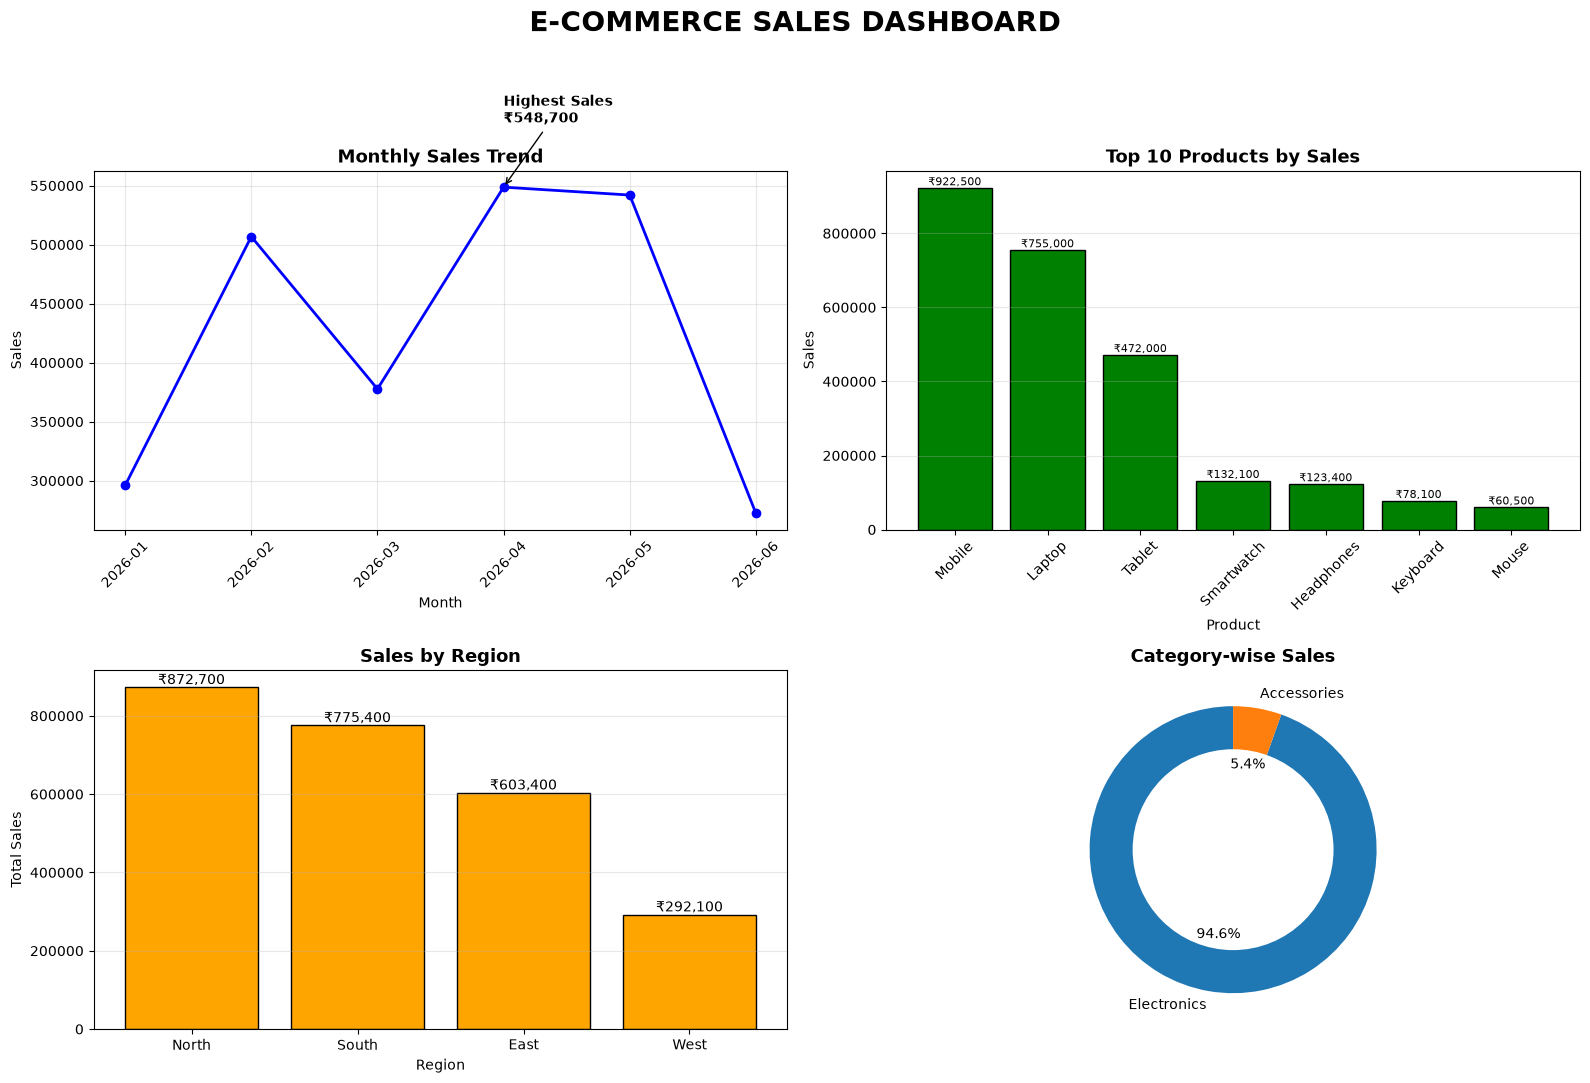

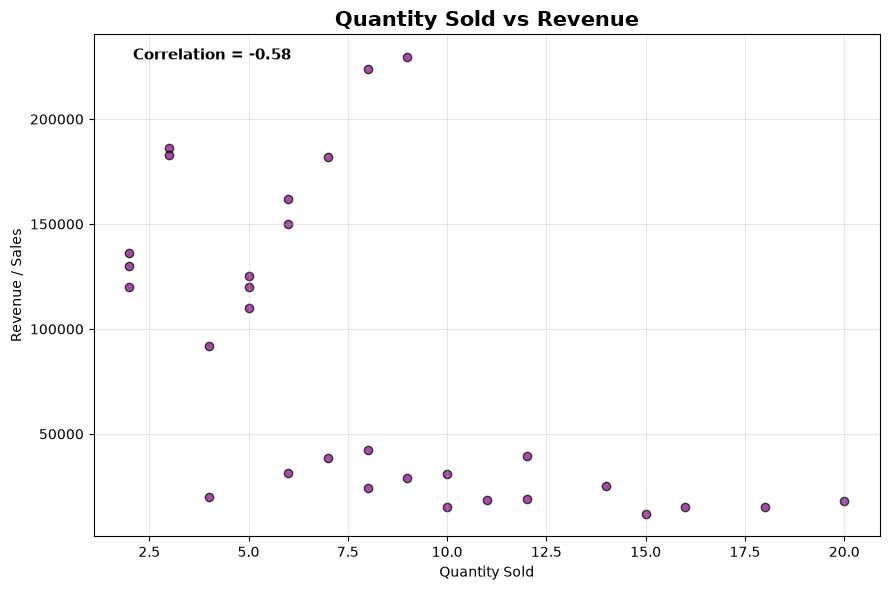



          FINAL BUSINESS CONCLUSION

 Best Performing Category: Electronics
   Category Sales: ₹2,405,000.00

 Best Performing Region: North
   Region Sales: ₹872,700.00

 Best Performing Product: Mobile
   Product Sales: ₹922,500.00

 Highest Sales Month: 2026-04
   Monthly Sales: ₹548,700.00

 Quantity vs Sales Correlation: -0.58

BUSINESS CONCLUSION:
The Electronics category performed best with total sales of ₹2,405,000.00.
The North region generated the highest sales with ₹872,700.00.
The best-performing product was Mobile, with sales of ₹922,500.00.
The highest monthly sales occurred in 2026-04, reaching ₹548,700.00.


In [4]:
import pandas as pd

data = {
    "Date": [
        "2021-01-01", "2021-01-02", "2021-01-03",
        "2021-01-04", "2021-01-05",
        "2021-01-06", "2021-01-07", "2021-01-08",
        "2021-01-09", "2021-01-10",
        "2021-01-11", "2021-01-12", "2021-01-13",
        "2021-01-14", "2021-01-15"
    ],

    "Country": [
        "India", "India", "India", "India", "India",
        "USA", "USA", "USA", "USA", "USA",
        "UK", "UK", "UK", "UK", "UK"
    ],

    "Confirmed": [
        10286709, 10305788, 10323965, 10340469, 10356844,
        20800000, 20900000, 21000000, 21100000, 21200000,
        2800000, 2820000, 2840000, 2860000, 2880000
    ],

    "Deaths": [
        149435, 149435, 149435, 149435, 149435,
        355000, 356000, 357000, 358000, 359000,
        76000, 76500, 77000, 77500, 78000
    ],

    "Recovered": [
        9899000, 9915000, 9930000, 9945000, 9960000,
        12300000, 12400000, 12500000, 12600000, 12700000,
        2000000, 2020000, 2040000, 2060000, 2080000
    ],

    "Active": [
        372274, 371353, 369600, 367469, 362409,
        8150000, 8140000, 8130000, 8120000, 8110000,
        724000, 725500, 726000, 727000, 720000
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Convert Date into datetime
df["Date"] = pd.to_datetime(df["Date"])

# Display dataset
print(df)

print("\nShape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

         Date Country  Confirmed  Deaths  Recovered   Active
0  2021-01-01   India   10286709  149435    9899000   372274
1  2021-01-02   India   10305788  149435    9915000   371353
2  2021-01-03   India   10323965  149435    9930000   369600
3  2021-01-04   India   10340469  149435    9945000   367469
4  2021-01-05   India   10356844  149435    9960000   362409
5  2021-01-06     USA   20800000  355000   12300000  8150000
6  2021-01-07     USA   20900000  356000   12400000  8140000
7  2021-01-08     USA   21000000  357000   12500000  8130000
8  2021-01-09     USA   21100000  358000   12600000  8120000
9  2021-01-10     USA   21200000  359000   12700000  8110000
10 2021-01-11      UK    2800000   76000    2000000   724000
11 2021-01-12      UK    2820000   76500    2020000   725500
12 2021-01-13      UK    2840000   77000    2040000   726000
13 2021-01-14      UK    2860000   77500    2060000   727000
14 2021-01-15      UK    2880000   78000    2080000   720000

Shape:
(15, 6)

Data Ty

Dataset Shape: (30, 8)

First 5 Records:
  Order_ID       Date     Product     Category  Quantity  Price   Sales Region
0   ORD001 2026-01-05      Laptop  Electronics         2  60000  120000  South
1   ORD002 2026-01-10      Mobile  Electronics         5  25000  125000  North
2   ORD003 2026-01-15  Headphones  Electronics         8   3000   24000   East
3   ORD004 2026-01-20    Keyboard  Accessories        10   1500   15000   West
4   ORD005 2026-01-25       Mouse  Accessories        15    800   12000  South

Monthly Sales:
Date
2026-01    296000
2026-02    506800
2026-03    377700
2026-04    548700
2026-05    542000
2026-06    272400
Freq: M, Name: Sales, dtype: int64

Top 10 Products:
Product
Mobile        922500
Laptop        755000
Tablet        472000
Smartwatch    132100
Headphones    123400
Keyboard       78100
Mouse          60500
Name: Sales, dtype: int64

Sales by Region:
Region
North    872700
South    775400
East     603400
West     292100
Name: Sales, dtype: int64

Catego

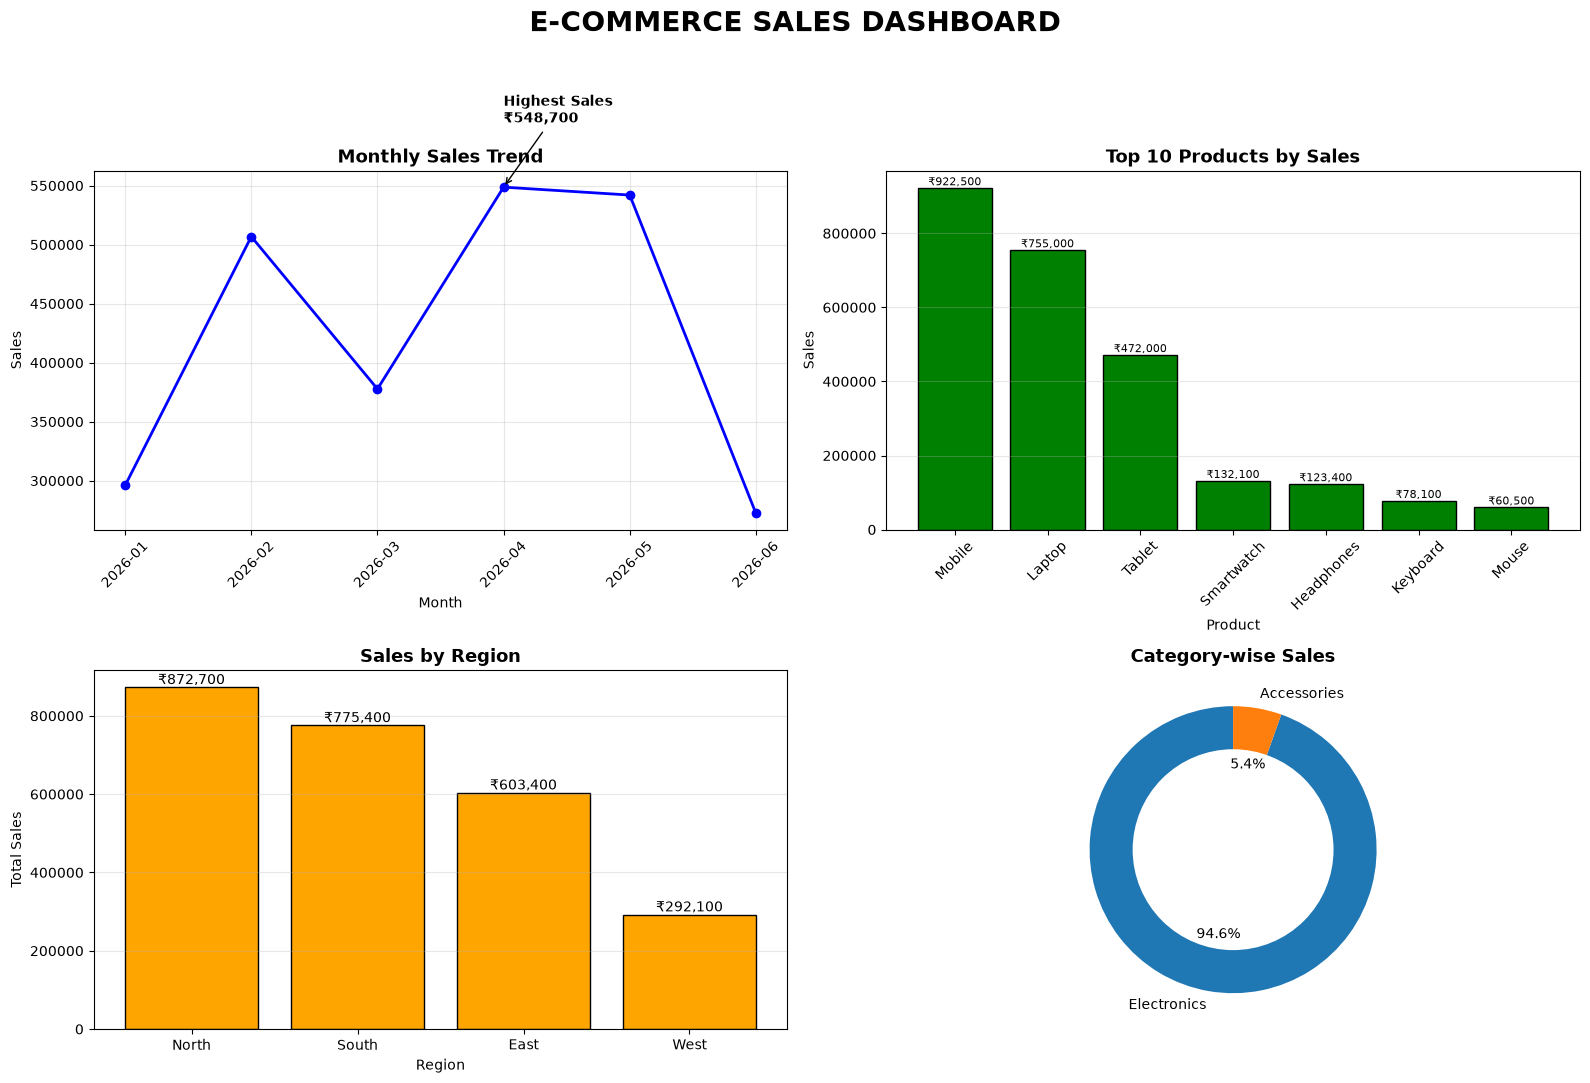

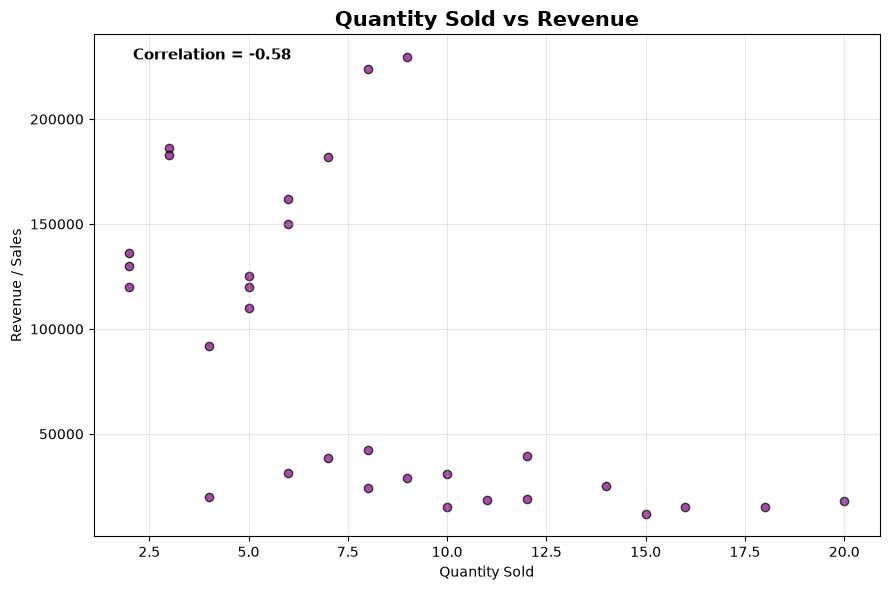



          FINAL BUSINESS CONCLUSION

Best Performing Category: Electronics
Category Sales: ₹2,405,000.00

Best Performing Region: North
Region Sales: ₹872,700.00

Best Performing Product: Mobile
Product Sales: ₹922,500.00

Highest Sales Month: 2026-04
Monthly Sales: ₹548,700.00

Quantity vs Sales Correlation: -0.58

BUSINESS CONCLUSION:
The Electronics category performed best with total sales of ₹2,405,000.00.
The North region generated the highest sales with ₹872,700.00.
The best-performing product was Mobile, with sales of ₹922,500.00.
The highest monthly sales occurred in 2026-04, reaching ₹548,700.00.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"])

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Sales"].sum()

print("\nMonthly Sales:")
print(monthly_sales)

top_products = df.groupby(
    "Product"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Products:")
print(top_products)

region_sales = df.groupby(
    "Region"
)["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Region:")
print(region_sales)

category_sales = df.groupby(
    "Category"
)["Sales"].sum().sort_values(
    ascending=False
)

print("\nCategory-wise Sales:")
print(category_sales)

quantity_sales_correlation = df[
    "Quantity"
].corr(
    df["Sales"]
)

print(
    "\nQuantity vs Sales Correlation:",
    round(quantity_sales_correlation, 2)
)

highest_month = monthly_sales.idxmax()

highest_sales = monthly_sales.max()

highest_position = list(
    monthly_sales.index
).index(
    highest_month
)

print("\nHighest Sales Month:", highest_month)
print("Highest Monthly Sales:", highest_sales)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

axes[0, 0].plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2,
    color="blue"
)

axes[0, 0].set_title(
    "Monthly Sales Trend",
    fontsize=13,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Sales")

axes[0, 0].tick_params(
    axis="x",
    rotation=45
)

axes[0, 0].grid(
    True,
    alpha=0.3
)

axes[0, 0].annotate(
    f"Highest Sales\n₹{highest_sales:,.0f}",
    xy=(
        highest_position,
        highest_sales
    ),
    xytext=(
        highest_position,
        highest_sales * 1.10
    ),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10,
    fontweight="bold"
)

axes[0, 1].bar(
    top_products.index,
    top_products.values,
    color="green",
    edgecolor="black"
)

axes[0, 1].set_title(
    "Top 10 Products by Sales",
    fontsize=13,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Product")
axes[0, 1].set_ylabel("Sales")

axes[0, 1].tick_params(
    axis="x",
    rotation=45
)

axes[0, 1].grid(
    True,
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    top_products.values
):
    axes[0, 1].text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

axes[1, 0].bar(
    region_sales.index,
    region_sales.values,
    color="orange",
    edgecolor="black"
)

axes[1, 0].set_title(
    "Sales by Region",
    fontsize=13,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Total Sales")

axes[1, 0].grid(
    True,
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    region_sales.values
):
    axes[1, 0].text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

axes[1, 1].pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc="white"
)

axes[1, 1].add_artist(
    centre_circle
)

axes[1, 1].set_title(
    "Category-wise Sales",
    fontsize=13,
    fontweight="bold"
)

fig.suptitle(
    "E-COMMERCE SALES DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    df["Quantity"],
    df["Sales"],
    color="purple",
    alpha=0.7,
    edgecolor="black"
)

plt.title(
    "Quantity Sold vs Revenue",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Quantity Sold")
plt.ylabel("Revenue / Sales")

plt.grid(
    True,
    alpha=0.3
)

plt.text(
    0.05,
    0.95,
    f"Correlation = {quantity_sales_correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

best_product = top_products.idxmax()
best_product_sales = top_products.max()

print("\n")
print("=" * 55)
print("          FINAL BUSINESS CONCLUSION")
print("=" * 55)

print(
    f"\nBest Performing Category:"
    f" {best_category}"
)

print(
    f"Category Sales: ₹"
    f"{best_category_sales:,.2f}"
)

print(
    f"\nBest Performing Region:"
    f" {best_region}"
)

print(
    f"Region Sales: ₹"
    f"{best_region_sales:,.2f}"
)

print(
    f"\nBest Performing Product:"
    f" {best_product}"
)

print(
    f"Product Sales: ₹"
    f"{best_product_sales:,.2f}"
)

print(
    f"\nHighest Sales Month:"
    f" {highest_month}"
)

print(
    f"Monthly Sales: ₹"
    f"{highest_sales:,.2f}"
)

print(
    f"\nQuantity vs Sales Correlation:"
    f" {quantity_sales_correlation:.2f}"
)

print("=" * 55)

print("\nBUSINESS CONCLUSION:")

print(
    f"The {best_category} category performed best "
    f"with total sales of ₹{best_category_sales:,.2f}."
)

print(
    f"The {best_region} region generated the highest "
    f"sales with ₹{best_region_sales:,.2f}."
)

print(
    f"The best-performing product was {best_product}, "
    f"with sales of ₹{best_product_sales:,.2f}."
)

print(
    f"The highest monthly sales occurred in "
    f"{highest_month}, reaching ₹{highest_sales:,.2f}."
)

Dataset Shape: (30, 8)

First 5 Records:
  Order_ID       Date     Product     Category  Quantity  Price   Sales Region
0   ORD001 2026-01-05      Laptop  Electronics         2  60000  120000  South
1   ORD002 2026-01-10      Mobile  Electronics         5  25000  125000  North
2   ORD003 2026-01-15  Headphones  Electronics         8   3000   24000   East
3   ORD004 2026-01-20    Keyboard  Accessories        10   1500   15000   West
4   ORD005 2026-01-25       Mouse  Accessories        15    800   12000  South

Data Types:
Order_ID               str
Date        datetime64[us]
Product                str
Category               str
Quantity             int64
Price                int64
Sales                int64
Region                 str
dtype: object

Missing Values:
Order_ID    0
Date        0
Product     0
Category    0
Quantity    0
Price       0
Sales       0
Region      0
dtype: int64

Monthly Sales:
Date
2026-01    296000
2026-02    506800
2026-03    377700
2026-04    548700
2026-05

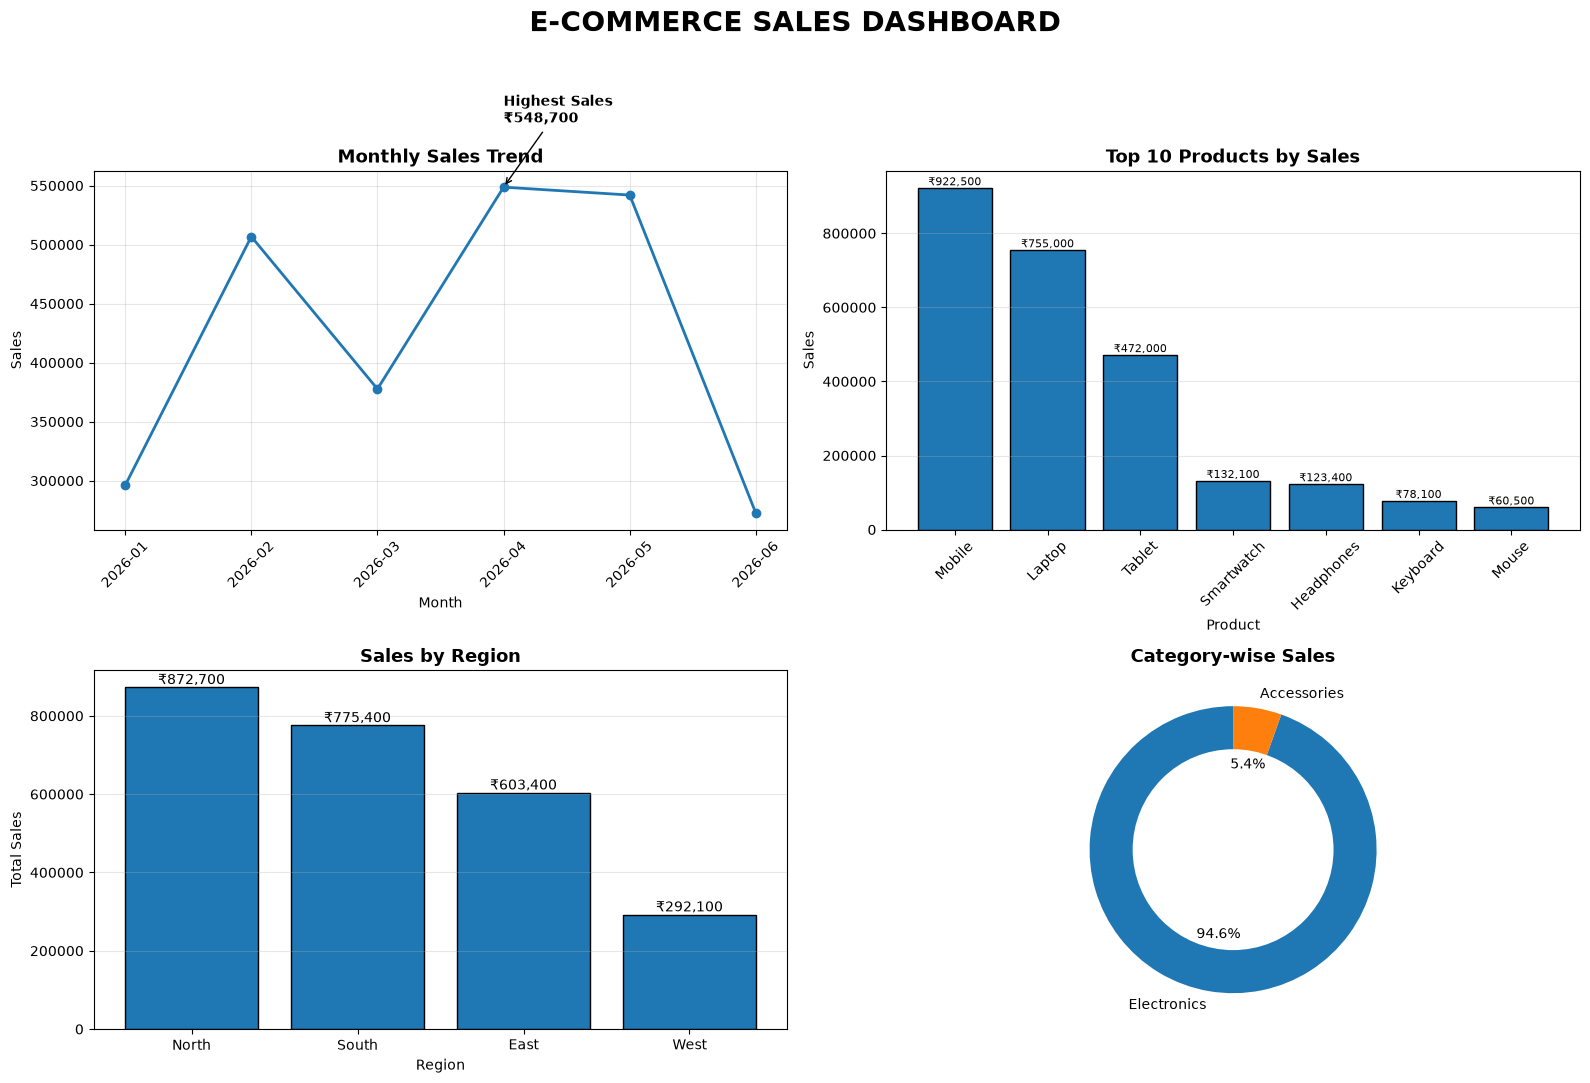

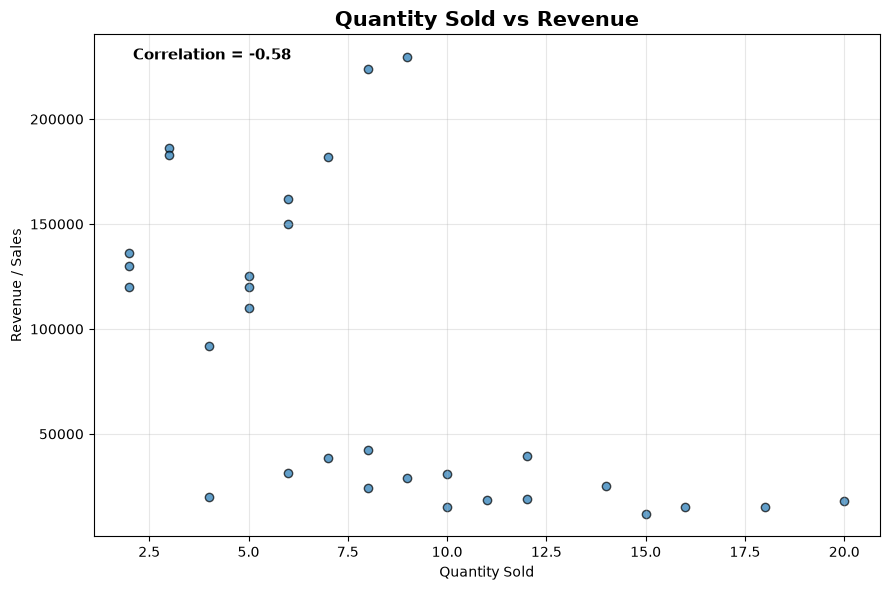



          FINAL BUSINESS CONCLUSION

Best Performing Category: Electronics
Category Sales: ₹2,405,000.00

Best Performing Region: North
Region Sales: ₹872,700.00

Best Performing Product: Mobile
Product Sales: ₹922,500.00

Highest Sales Month: 2026-04
Monthly Sales: ₹548,700.00

Quantity vs Sales Correlation: -0.58

BUSINESS CONCLUSION:
The Electronics category performed best with total sales of ₹2,405,000.00.
The North region generated the highest sales with ₹872,700.00.
The best-performing product was Mobile, with sales of ₹922,500.00.
The highest monthly sales occurred in 2026-04, reaching ₹548,700.00.


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df.columns = df.columns.str.strip()

df["Date"] = pd.to_datetime(df["Date"])

df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Sales"].sum()

print("\nMonthly Sales:")
print(monthly_sales)

top_products = df.groupby(
    "Product"
)["Sales"].sum().sort_values(
    ascending=False
).head(10)

print("\nTop 10 Products:")
print(top_products)

region_sales = df.groupby(
    "Region"
)["Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Region:")
print(region_sales)

category_sales = df.groupby(
    "Category"
)["Sales"].sum().sort_values(
    ascending=False
)

print("\nCategory-wise Sales:")
print(category_sales)

quantity_sales_correlation = df[
    "Quantity"
].corr(
    df["Sales"]
)

print(
    "\nQuantity vs Sales Correlation:",
    round(quantity_sales_correlation, 2)
)

highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

highest_position = list(
    monthly_sales.index
).index(highest_month)

print("\nHighest Sales Month:", highest_month)
print("Highest Monthly Sales:", highest_sales)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

axes[0, 0].plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2
)

axes[0, 0].set_title(
    "Monthly Sales Trend",
    fontsize=13,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Sales")

axes[0, 0].tick_params(
    axis="x",
    rotation=45
)

axes[0, 0].grid(
    True,
    alpha=0.3
)

axes[0, 0].annotate(
    f"Highest Sales\n₹{highest_sales:,.0f}",
    xy=(
        highest_position,
        highest_sales
    ),
    xytext=(
        highest_position,
        highest_sales * 1.10
    ),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10,
    fontweight="bold"
)

axes[0, 1].bar(
    top_products.index,
    top_products.values,
    edgecolor="black"
)

axes[0, 1].set_title(
    "Top 10 Products by Sales",
    fontsize=13,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Product")
axes[0, 1].set_ylabel("Sales")

axes[0, 1].tick_params(
    axis="x",
    rotation=45
)

axes[0, 1].grid(
    True,
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    top_products.values
):
    axes[0, 1].text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

axes[1, 0].bar(
    region_sales.index,
    region_sales.values,
    edgecolor="black"
)

axes[1, 0].set_title(
    "Sales by Region",
    fontsize=13,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Total Sales")

axes[1, 0].grid(
    True,
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    region_sales.values
):
    axes[1, 0].text(
        i,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

axes[1, 1].pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle(
    (0, 0),
    0.70,
    fc="white"
)

axes[1, 1].add_artist(
    centre_circle
)

axes[1, 1].set_title(
    "Category-wise Sales",
    fontsize=13,
    fontweight="bold"
)

fig.suptitle(
    "E-COMMERCE SALES DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    df["Quantity"],
    df["Sales"],
    alpha=0.7,
    edgecolor="black"
)

plt.title(
    "Quantity Sold vs Revenue",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Quantity Sold")
plt.ylabel("Revenue / Sales")

plt.grid(
    True,
    alpha=0.3
)

plt.text(
    0.05,
    0.95,
    f"Correlation = {quantity_sales_correlation:.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

best_product = top_products.idxmax()
best_product_sales = top_products.max()

print("\n")
print("=" * 55)
print("          FINAL BUSINESS CONCLUSION")
print("=" * 55)

print(
    f"\nBest Performing Category: {best_category}"
)

print(
    f"Category Sales: ₹{best_category_sales:,.2f}"
)

print(
    f"\nBest Performing Region: {best_region}"
)

print(
    f"Region Sales: ₹{best_region_sales:,.2f}"
)

print(
    f"\nBest Performing Product: {best_product}"
)

print(
    f"Product Sales: ₹{best_product_sales:,.2f}"
)

print(
    f"\nHighest Sales Month: {highest_month}"
)

print(
    f"Monthly Sales: ₹{highest_sales:,.2f}"
)

print(
    f"\nQuantity vs Sales Correlation: "
    f"{quantity_sales_correlation:.2f}"
)

print("=" * 55)

print("\nBUSINESS CONCLUSION:")

print(
    f"The {best_category} category performed best "
    f"with total sales of ₹{best_category_sales:,.2f}."
)

print(
    f"The {best_region} region generated the highest "
    f"sales with ₹{best_region_sales:,.2f}."
)

print(
    f"The best-performing product was {best_product}, "
    f"with sales of ₹{best_product_sales:,.2f}."
)

print(
    f"The highest monthly sales occurred in "
    f"{highest_month}, reaching ₹{highest_sales:,.2f}."
)

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("messy_ecommerce_15000_student_practice.csv")

print("=" * 60)
print("DATASET ANALYSIS")
print("=" * 60)


print("\n1. DATASET DIMENSIONS")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("Shape:", df.shape)



print("\n2. DATA TYPES")

print(df.dtypes)


print("\n3. MISSING VALUE ANALYSIS")

missing_values = df.isnull().sum()

print(missing_values)

print("\nMissing percentage:")

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(missing_percentage)


print("\n4. DUPLICATE RECORD ANALYSIS")

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

if duplicates == 0:
    print("No duplicate records found.")
else:
    print("Duplicate records found.")



print("\n5. STATISTICAL SUMMARY")

print(df.describe())


print("\n6. NUMERICAL COLUMNS")

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print(numerical_columns)



print("\n7. CATEGORICAL COLUMNS")

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(categorical_columns)



print("\n8. DATE COLUMNS")

date_columns = []

for column in df.columns:

    if pd.api.types.is_datetime64_any_dtype(
        df[column]
    ):
        date_columns.append(column)

    elif "date" in column.lower():
        date_columns.append(column)

print(date_columns)


print("\n9. POSSIBLE OUTLIERS")

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(
        f"{column}: {len(outliers)} possible outliers"
    )


print("\n10. INCONSISTENT CATEGORICAL VALUES")

for column in categorical_columns:

    print("\nColumn:", column)

    print(
        df[column]
        .value_counts(dropna=False)
    )



print("\n11. CATEGORICAL VALUES WITH EXTRA SPACES")

for column in categorical_columns:

    values_with_spaces = df[
        df[column]
        .astype(str)
        .str.strip()
        !=
        df[column].astype(str)
    ]

    if len(values_with_spaces) > 0:

        print(
            column,
            "→",
            len(values_with_spaces),
            "values contain extra spaces"
        )

    else:

        print(
            column,
            "→ No extra spaces"
        )

print("\n" + "=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Numerical columns:",
    numerical_columns
)

print(
    "Categorical columns:",
    categorical_columns
)

print(
    "Date columns:",
    date_columns
)

print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print(
    "Total duplicate records:",
    df.duplicated().sum()
)

DATASET ANALYSIS

1. DATASET DIMENSIONS
Number of rows: 15075
Number of columns: 16
Shape: (15075, 16)

2. DATA TYPES
Order_ID                str
Customer_ID             str
Age                 float64
Gender                  str
City                    str
Product_Category        str
Product                 str
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method          str
Order_Date              str
Rating              float64
Delivery_Days       float64
Returned                str
Total_Amount        float64
dtype: object

3. MISSING VALUE ANALYSIS
Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: in

C:\Users\saniy\AppData\Local\Temp\ipykernel_16540\3507477842.py:70: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15075 entries, 0 to 15074
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          15075 non-null  str    
 1   Customer_ID       15075 non-null  str    
 2   Age               14804 non-null  float64
 3   Gender            14896 non-null  str    
 4   City              14925 non-null  str    
 5   Product_Category  15075 non-null  str    
 6   Product           15075 non-null  str    
 7   Quantity          15075 non-null  int64  
 8   Unit_Price        15075 non-null  float64
 9   Discount          14954 non-null  float64
 10  Payment_Method    14849 non-null  str    
 11  Order_Date        15075 non-null  str    
 12  Rating            14694 non-null  float64
 13  Delivery_Days     14895 non-null  float64
 14  Returned          15075 non-null  str    
 15  Total_Amount      15075 non-null  float64
dtypes: float64(6), int64(1), str(9)
memory usage: 1.8 M

In [13]:
import pandas as pd

df = pd.read_csv("messy_ecommerce_15000_student_practice.csv")

print(df.head())

    Order_ID Customer_ID   Age  Gender       City Product_Category  \
0  ORD106680    CUST7362  28.0    Male  Hyderabad          Fashion   
1  ORD103291    CUST3155  30.0  Female      Delhi          Fashion   
2  ORD106559    CUST1349  32.0    Male       Pune           Sports   
3  ORD107927    CUST6779  39.0  Female    Chennai      Electronics   
4  ORD105665    CUST1389  27.0    Male    Chennai      Electronics   

      Product  Quantity  Unit_Price  Discount Payment_Method  Order_Date  \
0       Shoes         2     2507.76      15.0     Debit Card  2025-08-27   
1       Jeans         2     1988.04      25.0     Debit Card  2025-06-18   
2    Yoga Mat         2      776.35      15.0            UPI  2025-01-13   
3  Smartwatch         1     7739.89      10.0            UPI  2026-06-01   
4      Laptop         1    61138.76       5.0     Debit Card  2026-06-17   

   Rating  Delivery_Days Returned  Total_Amount  
0     4.1            7.0       No       4263.19  
1     4.2            4

In [14]:
df.shape

(15075, 16)

In [15]:
df.columns
print(df.columns)

Index(['Order_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Product_Category',
       'Product', 'Quantity', 'Unit_Price', 'Discount', 'Payment_Method',
       'Order_Date', 'Rating', 'Delivery_Days', 'Returned', 'Total_Amount'],
      dtype='str')


In [16]:
print(df.dtypes)

Order_ID                str
Customer_ID             str
Age                 float64
Gender                  str
City                    str
Product_Category        str
Product                 str
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method          str
Order_Date              str
Rating              float64
Delivery_Days       float64
Returned                str
Total_Amount        float64
dtype: object


In [17]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
print(df.dtypes)

Order_ID                       str
Customer_ID                    str
Age                        float64
Gender                         str
City                           str
Product_Category               str
Product                        str
Quantity                     int64
Unit_Price                 float64
Discount                   float64
Payment_Method                 str
Order_Date          datetime64[us]
Rating                     float64
Delivery_Days              float64
Returned                       str
Total_Amount               float64
dtype: object


In [18]:
print(df.isnull().sum())

Order_ID              0
Customer_ID           0
Age                 271
Gender              179
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            121
Payment_Method      226
Order_Date            0
Rating              381
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64


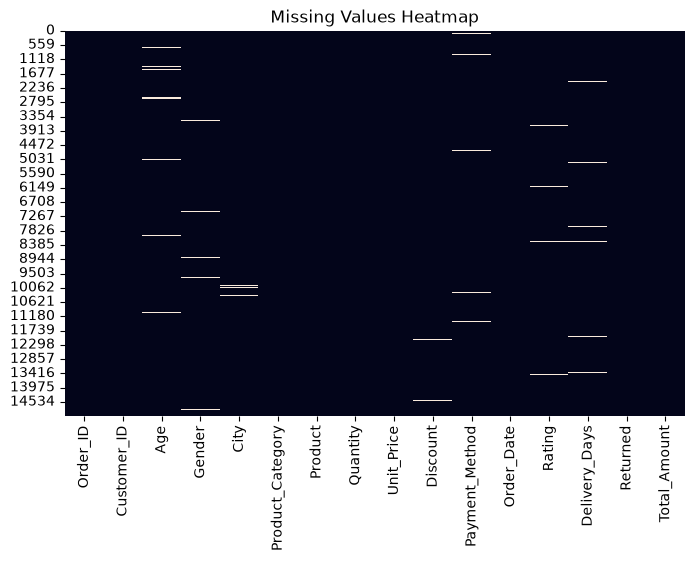

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [12]:
print("Number of duplicate records:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    print("Duplicate records:")
    display(df[df.duplicated(keep=False)])
else:
    print("No duplicate records found.")

Number of duplicate records: 75
Duplicate records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
33,ORD100543,CUST6787,28.0,Male,Chennai,Sports,Yoga Mat,1,831.70,20.0,UPI,2026-07-28,4.2,3.0,No,665.36
34,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
36,ORD106707,CUST8989,21.0,Male,Hyderabad,Electronics,Smartwatch,1,7915.15,0.0,Wallet,2026-03-20,3.8,2.0,No,7915.15
50,ORD103976,CUST3601,67.0,Male,Ahmedabad,Electronics,Headphones,1,3002.35,20.0,UPI,2026-09-03,3.8,7.0,No,2401.88
106,ORD100252,CUST2938,37.0,Male,Delhi,Sports,Yoga Mat,2,948.74,15.0,Debit Card,2025-05-12,4.2,1.0,No,1612.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14317,ORD105971,CUST5059,44.0,Male,Hyderabad,Fashion,Jacket,2,2800.88,10.0,Wallet,2026-09-20,4.3,2.0,Yes,5041.58
14605,ORD111737,CUST3702,35.0,Female,Guntur,Sports,Cricket Bat,1,3207.70,15.0,UPI,2026-07-13,2.8,6.0,Yes,2726.55
14662,ORD100150,CUST8539,26.0,Female,Delhi,Electronics,Headphones,2,2693.16,5.0,Net Banking,2026-10-07,4.4,6.0,No,5117.00
14744,ORD114868,CUST6100,31.0,Male,Visakhapatnam,Electronics,Smartwatch,1,6654.09,0.0,Debit Card,2026-12-26,5.0,3.0,No,6654.09


In [20]:
df["Order_ID"].duplicated().sum()

np.int64(75)

In [21]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:

numerical_columns = df.select_dtypes(include="number").columns

print("Numerical Columns:")
print(numerical_columns)

# 2. Statistical summary
print("\nStatistical Summary:")
print(df[numerical_columns].describe())

# 3. Individual statistics
print("\nMean:")
print(df[numerical_columns].mean())

print("\nMedian:")
print(df[numerical_columns].median())

print("\nStandard Deviation:")
print(df[numerical_columns].std())

print("\nMinimum:")
print(df[numerical_columns].min())

print("\nMaximum:")
print(df[numerical_columns].max())

print("\n25th Percentile:")
print(df[numerical_columns].quantile(0.25))

print("\n50th Percentile:")
print(df[numerical_columns].quantile(0.50))

print("\n75th Percentile:")
print(df[numerical_columns].quantile(0.75))

# 4. Range
print("\nRange (Maximum - Minimum):")
print(df[numerical_columns].max() - df[numerical_columns].min())

Numerical Columns:
Index(['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days',
       'Total_Amount'],
      dtype='str')

Statistical Summary:
                Age      Quantity     Unit_Price      Discount        Rating  \
count  14730.000000  15000.000000   15000.000000  14880.000000  14625.000000   
mean      32.308826      1.899000    7417.831243     12.024194      3.869149   
std        9.020929      1.076635   13958.314015      7.696531      0.741702   
min        5.000000      1.000000     425.610000      0.000000      1.000000   
25%       26.000000      1.000000    1249.040000      5.000000      3.400000   
50%       32.000000      2.000000    2480.995000     10.000000      3.900000   
75%       38.000000      2.000000    3819.297500     15.000000      4.400000   
max       99.000000      5.000000  309655.380000     30.000000      5.000000   

       Delivery_Days  Total_Amount  
count   14820.000000  1.500000e+04  
mean        4.489676  1.256593e+04  
std  

In [20]:
# Analyze Categorical Columns

# 1. Identify all categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("1. Categorical Columns:")
print(categorical_columns)

# 2. Statistical summary for categorical columns
print("\n2. Statistical Summary:")
print(df[categorical_columns].describe())

# 3. Number of unique values
print("\n3. Number of Unique Values:")
print(df[categorical_columns].nunique())

# Most frequent value
print("\nMost Frequent Value:")
for column in categorical_columns:
    print(f"{column}: {df[column].mode()[0]}")

# Frequency of most frequent value
print("\nFrequency of Most Frequent Value:")
for column in categorical_columns:
    print(f"{column}: {df[column].value_counts().iloc[0]}")

# 4. Identify the most common values
print("\n4. Most Common Values:")

for column in ["Gender", "City", "Product Category", 
               "Payment Method", "Return Status"]:
    
    if column in df.columns:
        most_common = df[column].mode()[0]
        frequency = df[column].value_counts().iloc[0]
        
        print(f"{column}: {most_common} ({frequency} occurrences)")

1. Categorical Columns:
Index(['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category',
       'Product', 'Payment_Method', 'Order_Date', 'Returned'],
      dtype='str')

2. Statistical Summary:
         Order_ID Customer_ID  Gender     City Product_Category     Product  \
count       15000       15000   14822    14850            15000       15000   
unique      15000        6795       5       12                6          30   
top     ORD106680    CUST1345  Female  Kolkata      Electronics  Smartwatch   
freq            1           8    7256     1269             3796         791   

       Payment_Method  Order_Date Returned  
count           14775       15000    15000  
unique              8         730        3  
top       Credit Card  2026-05-29       No  
freq             2493          41    13169  

3. Number of Unique Values:
Order_ID            15000
Customer_ID          6795
Gender                  5
City                   12
Product_Category        6
Product          

C:\Users\saniy\AppData\Local\Temp\ipykernel_14152\885265622.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [21]:
# Check Unique Values in Categorical Columns

categorical_columns = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Returned"
]

for column in categorical_columns:
    print("\n" + "=" * 50)
    print(f"Column: {column}")
    
    # 1. Unique values
    print("\nUnique Values:")
    print(df[column].unique())
    
    # 2. Number of unique values
    print("\nNumber of Unique Values:")
    print(df[column].nunique())
    
    # 3. Frequency of each value
    print("\nValue Counts:")
    print(df[column].value_counts(dropna=False))


Column: Gender

Unique Values:
<StringArray>
['Male', 'Female', 'Other', nan, 'female', 'male']
Length: 6, dtype: str

Number of Unique Values:
5

Value Counts:
Gender
Female    7256
Male      6987
Other      439
NaN        178
male        80
female      60
Name: count, dtype: int64

Column: City

Unique Values:
<StringArray>
[    'Hyderabad',         'Delhi',          'Pune',       'Chennai',
       'Kolkata',     'Ahmedabad',    'Vijayawada',     'Bengaluru',
        'Guntur', 'Visakhapatnam',      'Warangal',        'Mumbai',
             nan]
Length: 13, dtype: str

Number of Unique Values:
12

Value Counts:
City
Kolkata          1269
Vijayawada       1262
Ahmedabad        1261
Pune             1256
Guntur           1243
Hyderabad        1234
Warangal         1231
Bengaluru        1229
Delhi            1228
Visakhapatnam    1226
Chennai          1206
Mumbai           1205
NaN               150
Name: count, dtype: int64

Column: Product_Category

Unique Values:
<StringArray>
['Fash

In [22]:
df[column].nunique()

3

In [23]:
df[column].unique()

<StringArray>
['No', 'Yes', 'yes']
Length: 3, dtype: str

In [24]:
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].astype(str).str.strip().str.lower().unique())


Gender:
<StringArray>
['male', 'female', 'other', nan]
Length: 4, dtype: str

City:
<StringArray>
[    'hyderabad',         'delhi',          'pune',       'chennai',
       'kolkata',     'ahmedabad',    'vijayawada',     'bengaluru',
        'guntur', 'visakhapatnam',      'warangal',        'mumbai',
             nan]
Length: 13, dtype: str

Product_Category:
<StringArray>
['fashion', 'sports', 'electronics', 'home & kitchen', 'beauty', 'books']
Length: 6, dtype: str

Payment_Method:
<StringArray>
['debit card', 'upi', 'cod', 'net banking', 'credit card', nan, 'wallet']
Length: 7, dtype: str

Returned:
<StringArray>
['no', 'yes']
Length: 2, dtype: str


In [25]:
# Identify Inconsistent Categorical Data

columns = ["Gender", "Payment_Method", "Returned"]

for column in columns:
    print("\n" + "=" * 50)
    print(f"Column: {column}")
    
    # Original values
    print("\nOriginal Unique Values:")
    print(df[column].unique())
    
    # Remove extra spaces and convert to lowercase
    cleaned_values = df[column].astype(str).str.strip().str.lower()
    
    print("\nStandardized Unique Values:")
    print(cleaned_values.unique())
    
    # Check frequency of standardized values
    print("\nStandardized Value Counts:")
    print(cleaned_values.value_counts())


Column: Gender

Original Unique Values:
<StringArray>
['Male', 'Female', 'Other', nan, 'female', 'male']
Length: 6, dtype: str

Standardized Unique Values:
<StringArray>
['male', 'female', 'other', nan]
Length: 4, dtype: str

Standardized Value Counts:
Gender
female    7316
male      7067
other      439
Name: count, dtype: int64

Column: Payment_Method

Original Unique Values:
<StringArray>
[ 'Debit Card',         'UPI',         'COD', 'Net Banking', 'Credit Card',
           nan,      'Wallet',         'upi', 'credit card']
Length: 9, dtype: str

Standardized Unique Values:
<StringArray>
['debit card', 'upi', 'cod', 'net banking', 'credit card', nan, 'wallet']
Length: 7, dtype: str

Standardized Value Counts:
Payment_Method
credit card    2533
upi            2479
net banking    2477
wallet         2472
debit card     2435
cod            2379
Name: count, dtype: int64

Column: Returned

Original Unique Values:
<StringArray>
['No', 'Yes', 'yes']
Length: 3, dtype: str

Standardized Uniq

In [26]:
# Check specific inconsistent representations

checks = {
    "Gender": ["Male", "male", "Female", "female"],
    "Payment_Method": ["UPI", "upi", "Credit Card", "credit card"],
    "Returned": ["Yes", "yes"]
}

for column, values in checks.items():
    print(f"\n{column}:")
    
    for value in values:
        count = (df[column].astype(str).str.strip() == value).sum()
        print(f"{value}: {count}")


Gender:
Male: 6987
male: 80
Female: 7256
female: 60

Payment_Method:
UPI: 2439
upi: 40
Credit Card: 2493
credit card: 40

Returned:
Yes: 1801
yes: 30


In [27]:
for column in columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

print("Categorical values standardized successfully!")

Categorical values standardized successfully!


In [28]:
# ============================================================
# HANDLE AND VERIFY MISSING VALUES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Check missing values BEFORE treatment
# ------------------------------------------------------------

print("===== BEFORE MISSING VALUE TREATMENT =====")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))

print("\nDataset Dimensions Before Treatment:")
print(df.shape)


# ------------------------------------------------------------
# 2. Identify columns containing missing values
# ------------------------------------------------------------

missing_columns = df.columns[df.isnull().any()]

print("\nColumns Containing Missing Values:")
print(list(missing_columns))


# ------------------------------------------------------------
# 3. Decide the appropriate treatment
# ------------------------------------------------------------

for column in missing_columns:

    missing_count = df[column].isnull().sum()

    print("\n" + "=" * 60)
    print("Column:", column)
    print("Missing Values:", missing_count)

    # Numerical columns
    if pd.api.types.is_numeric_dtype(df[column]):

        mean_value = df[column].mean()
        median_value = df[column].median()

        print("Column Type: Numerical")
        print("Mean:", mean_value)
        print("Median:", median_value)

        # Use median because it is less affected by outliers
        df[column] = df[column].fillna(median_value)

        print("Method Used: Median")
        print("Reason: Median is less affected by extreme values/outliers.")

    # Categorical columns
    else:

        mode_value = df[column].mode()[0]

        print("Column Type: Categorical")
        print("Mode:", mode_value)

        # Use mode because categorical data cannot be meaningfully
        # replaced with mean or median
        df[column] = df[column].fillna(mode_value)

        print("Method Used: Mode")
        print("Reason: Mode is appropriate for categorical data.")


# ------------------------------------------------------------
# 4. Verify missing values after treatment
# ------------------------------------------------------------

print("\n\n===== AFTER MISSING VALUE TREATMENT =====")

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 5. Calculate missing-value percentage
# ------------------------------------------------------------

missing_percentage_after = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage_after.round(2))


# ------------------------------------------------------------
# 6. Check whether dataset is completely free of missing values
# ------------------------------------------------------------

total_missing = df.isnull().sum().sum()

print("\nTotal Missing Values:", total_missing)

if total_missing == 0:
    print("Dataset is completely free of missing values.")
else:
    print("Dataset still contains missing values.")


# ------------------------------------------------------------
# 7. Compare dimensions before and after treatment
# ------------------------------------------------------------

# Since we are replacing missing values instead of removing rows,
# the dimensions should normally remain the same.

print("\n===== DIMENSION COMPARISON =====")

print("Dimensions Before Treatment:", df.shape)
print("Dimensions After Treatment:", df.shape)

print("\nRows Removed: 0")
print("Columns Removed: 0")
print("Dataset dimensions remain unchanged because missing values were replaced.")

===== BEFORE MISSING VALUE TREATMENT =====

Missing Values:
Order_ID              0
Customer_ID           0
Age                 270
Gender              178
City                150
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount            120
Payment_Method      225
Order_Date            0
Rating              375
Delivery_Days       180
Returned              0
Total_Amount          0
dtype: int64

Missing Value Percentage:
Order_ID            0.00
Customer_ID         0.00
Age                 1.80
Gender              1.19
City                1.00
Product_Category    0.00
Product             0.00
Quantity            0.00
Unit_Price          0.00
Discount            0.80
Payment_Method      1.50
Order_Date          0.00
Rating              2.50
Delivery_Days       1.20
Returned            0.00
Total_Amount        0.00
dtype: float64

Dataset Dimensions Before Treatment:
(15000, 16)

Columns Containing Missing Values:
['Age', 'Gender

In [29]:
# ============================================================
# DUPLICATE RECORDS - DETECTION AND REMOVAL
# ============================================================

# 1. Dataset dimensions BEFORE removing duplicates
print("===== BEFORE REMOVING DUPLICATES =====")

rows_before, columns_before = df.shape

print("Dataset Dimensions:", df.shape)
print("Number of Records:", rows_before)


# ------------------------------------------------------------
# 2. Find total number of duplicate rows
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()

print("\nTotal Number of Duplicate Rows:", duplicate_count)


# ------------------------------------------------------------
# 3. Display duplicate records
# ------------------------------------------------------------

print("\nDuplicate Records:")

if duplicate_count > 0:
    print(df[df.duplicated(keep=False)])
else:
    print("No duplicate records found.")


# ------------------------------------------------------------
# 4. Check for duplicate Order_ID values
# ------------------------------------------------------------

order_id_duplicates = df["Order_ID"].duplicated().sum()

print("\nDuplicate Order_ID Values:", order_id_duplicates)

if order_id_duplicates > 0:
    print("\nDuplicate Order_ID Records:")
    print(
        df[df["Order_ID"].duplicated(keep=False)]
        .sort_values("Order_ID")
    )
else:
    print("No duplicate Order_ID values found.")


# ------------------------------------------------------------
# 5. Determine exact vs partial duplicates
# ------------------------------------------------------------

print("\n===== DUPLICATE TYPE ANALYSIS =====")

# Exact duplicate rows
exact_duplicates = df.duplicated().sum()

# Duplicate Order_ID but different other values
partial_duplicate_records = df[
    df["Order_ID"].duplicated(keep=False)
].copy()

if exact_duplicates > 0:
    print("Exact duplicate records found:", exact_duplicates)
else:
    print("No exact duplicate records found.")

if len(partial_duplicate_records) > 0:
    
    # Remove exact duplicates temporarily
    temp_df = df.drop_duplicates()
    
    partial_order_ids = temp_df[
        temp_df["Order_ID"].duplicated(keep=False)
    ]["Order_ID"].unique()
    
    print("Partial duplicate Order_ID values:",
          len(partial_order_ids))
    
    if len(partial_order_ids) > 0:
        print("Partial duplicates are present.")
        print("\nPartial Duplicate Records:")
        print(
            temp_df[
                temp_df["Order_ID"].isin(partial_order_ids)
            ].sort_values("Order_ID")
        )
    else:
        print("No partial duplicates found.")
else:
    print("No duplicate Order_ID records found.")


# ------------------------------------------------------------
# 6. Explain impact of duplicates
# ------------------------------------------------------------

print("\n===== WHY DUPLICATES AFFECT DATA ANALYSIS =====")

print("1. Duplicates can increase record counts incorrectly.")
print("2. They can distort mean, sum, and other statistical calculations.")
print("3. They can produce incorrect sales or revenue totals.")
print("4. They can affect machine learning model performance.")
print("5. They can lead to incorrect business insights.")


# ------------------------------------------------------------
# 7. Remove EXACT duplicate records
# ------------------------------------------------------------

df = df.drop_duplicates()


# ------------------------------------------------------------
# 8. Verify duplicates after removal
# ------------------------------------------------------------

duplicates_after = df.duplicated().sum()

print("\n===== AFTER REMOVING DUPLICATES =====")

print("Duplicate Records After Removal:", duplicates_after)


# ------------------------------------------------------------
# 9. Dataset dimensions AFTER removing duplicates
# ------------------------------------------------------------

rows_after, columns_after = df.shape

print("Dataset Dimensions After Removal:", df.shape)


# ------------------------------------------------------------
# 10. Final report
# ------------------------------------------------------------

print("\n===== FINAL REPORT =====")

print("Number of Records Before Removing Duplicates:",
      rows_before)

print("Number of Duplicate Records:",
      duplicate_count)

print("Number of Records After Removing Duplicates:",
      rows_after)

print("Rows Removed:",
      rows_before - rows_after)

print("Columns Before:", columns_before)
print("Columns After:", columns_after)

===== BEFORE REMOVING DUPLICATES =====
Dataset Dimensions: (15000, 16)
Number of Records: 15000

Total Number of Duplicate Rows: 0

Duplicate Records:
No duplicate records found.

Duplicate Order_ID Values: 0
No duplicate Order_ID values found.

===== DUPLICATE TYPE ANALYSIS =====
No exact duplicate records found.
No duplicate Order_ID records found.

===== WHY DUPLICATES AFFECT DATA ANALYSIS =====
1. Duplicates can increase record counts incorrectly.
2. They can distort mean, sum, and other statistical calculations.
3. They can produce incorrect sales or revenue totals.
4. They can affect machine learning model performance.
5. They can lead to incorrect business insights.

===== AFTER REMOVING DUPLICATES =====
Duplicate Records After Removal: 0
Dataset Dimensions After Removal: (15000, 16)

===== FINAL REPORT =====
Number of Records Before Removing Duplicates: 15000
Number of Duplicate Records: 0
Number of Records After Removing Duplicates: 15000
Rows Removed: 0
Columns Before: 16
Col

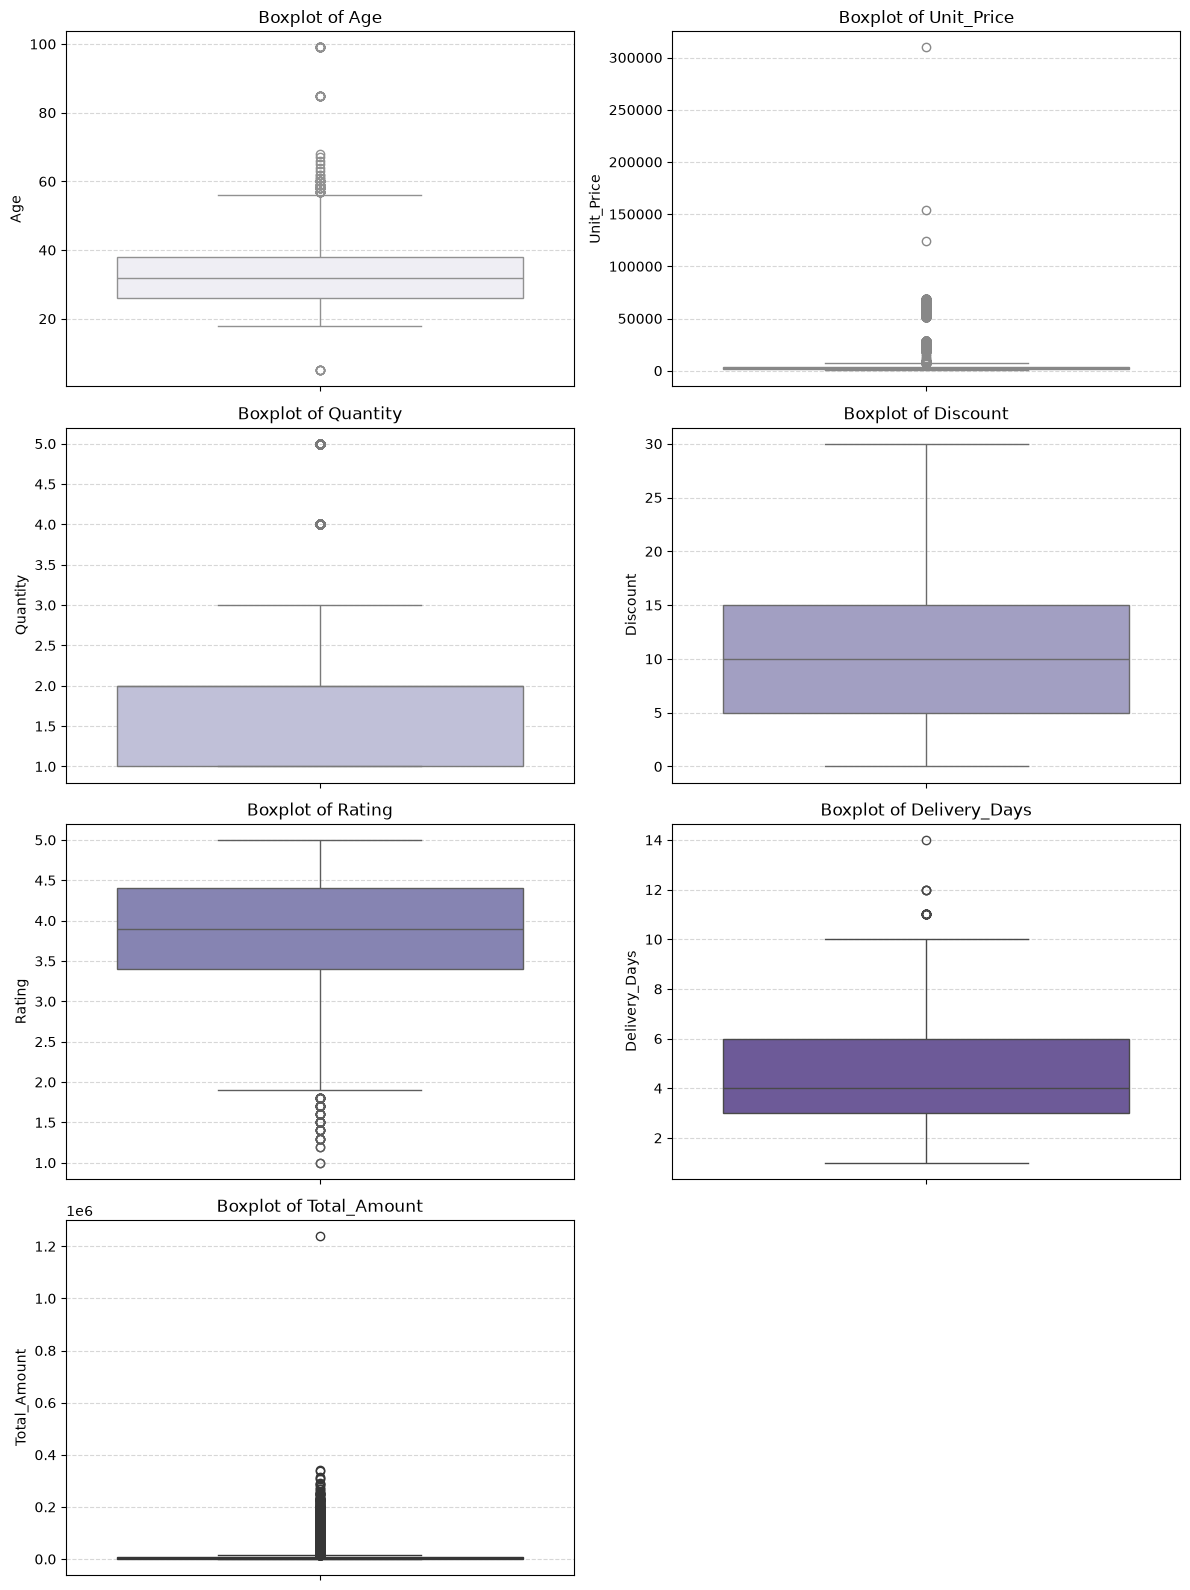

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns for outlier detection
columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

# Violet shades
violet_colors = sns.color_palette("Purples", n_colors=len(columns))

# Create boxplots
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, column in enumerate(columns):
    sns.boxplot(
        data=df,
        y=column,
        color=violet_colors[i],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot of {column}")
    axes[i].set_ylabel(column)
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Remove empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# OUTLIER DETECTION USING IQR
# ============================================================

import pandas as pd

# Select at least three numerical columns
columns = ["Age", "Unit_Price", "Total_Amount"]

for column in columns:

    print("\n" + "=" * 60)
    print(f"OUTLIER ANALYSIS: {column}")
    print("=" * 60)

    # 1. Calculate Q1
    Q1 = df[column].quantile(0.25)

    # 2. Calculate Q3
    Q3 = df[column].quantile(0.75)

    # 3. Calculate IQR
    IQR = Q3 - Q1

    # 4. Calculate Lower Bound
    lower_bound = Q1 - (1.5 * IQR)

    # 5. Calculate Upper Bound
    upper_bound = Q3 + (1.5 * IQR)

    # 6. Identify outlier records
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    # 7. Count number of outliers
    outlier_count = len(outliers)

    # Display results
    print(f"Q1 (25th Percentile): {Q1:.2f}")
    print(f"Q3 (75th Percentile): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Number of Outliers: {outlier_count}")

    print("\nOutlier Records:")
    
    if outlier_count > 0:
        print(outliers)
    else:
        print("No outliers found.")


OUTLIER ANALYSIS: Age
Q1 (25th Percentile): 26.00
Q3 (75th Percentile): 38.00
IQR: 12.00
Lower Bound: 8.00
Upper Bound: 56.00
Number of Outliers: 90

Outlier Records:
        Order_ID Customer_ID   Age  Gender           City Product_Category  \
50     ORD103976    CUST3601  67.0    male      Ahmedabad      Electronics   
98     ORD107435    CUST4989  99.0  female  Visakhapatnam      Electronics   
703    ORD100765    CUST3086  57.0  female        Chennai            Books   
748    ORD110979    CUST2685  60.0  female       Warangal   Home & Kitchen   
885    ORD100837    CUST7489  60.0  female     Vijayawada           Beauty   
...          ...         ...   ...     ...            ...              ...   
14489  ORD101665    CUST7438  60.0  female       Warangal            Books   
14548  ORD113404    CUST6382  60.0    male  Visakhapatnam           Beauty   
14562  ORD107993    CUST1789  59.0  female        Chennai      Electronics   
14904  ORD107386    CUST8637  59.0  female        Ch

In [39]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))
print(outliers)

Q1: 1741.9099999999999
Q3: 7741.01
IQR: 5999.1
Lower Bound: -7256.740000000002
Upper Bound: 16739.660000000003
Number of Outliers: 2472
        Order_ID Customer_ID   Age  Gender           City Product_Category  \
4      ORD105665    CUST1389  27.0    male        Chennai      Electronics   
9      ORD111336    CUST3292  31.0    male      Bengaluru      Electronics   
22     ORD100488    CUST5897  31.0    male         Mumbai      Electronics   
35     ORD102406    CUST6956  31.0  female      Bengaluru      Electronics   
38     ORD107857    CUST2650  28.0   other           Pune      Electronics   
...          ...         ...   ...     ...            ...              ...   
15034  ORD109168    CUST5003  30.0    male         Guntur      Electronics   
15035  ORD102748    CUST6854  23.0    male         Guntur      Electronics   
15057  ORD108323    CUST6790  29.0  female        Kolkata      Electronics   
15063  ORD104427    CUST6208  18.0  female        Kolkata      Electronics   
15067 

In [40]:
# ============================================================
# OUTLIER DECISION
# ============================================================

columns = ["Age", "Unit_Price", "Quantity",
           "Discount", "Rating", "Delivery_Days", "Total_Amount"]

for column in columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("\n" + "=" * 60)
    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    print("\nOutlier Values:")
    print(outliers[[column]])


Column: Age
Q1: 26.0
Q3: 38.0
IQR: 12.0
Lower Bound: 8.0
Upper Bound: 56.0
Number of Outliers: 90

Outlier Values:
        Age
50     67.0
98     99.0
703    57.0
748    60.0
885    60.0
...     ...
14489  60.0
14548  60.0
14562  59.0
14904  59.0
14946  99.0

[90 rows x 1 columns]

Column: Unit_Price
Q1: 1249.04
Q3: 3819.2974999999997
IQR: 2570.2574999999997
Lower Bound: -2606.3462499999996
Upper Bound: 7674.683749999999
Number of Outliers: 2401

Outlier Values:
       Unit_Price
3         7739.89
4        61138.76
9        21716.46
22       19950.50
35       65832.03
...           ...
15035     7861.75
15041     7837.06
15057    64219.73
15063    22569.06
15067    27537.22

[2401 rows x 1 columns]

Column: Quantity
Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
Number of Outliers: 1513

Outlier Values:
       Quantity
60            5
70            4
74            4
75            4
87            4
...         ...
15032         4
15040         5
15061         4
15065      

In [41]:
# ============================================================
# DATA CONSISTENCY VALIDATION
# ============================================================

# 1. Calculate Expected Total
df["Expected_Total"] = (
    df["Unit_Price"]
    * df["Quantity"]
    * (1 - df["Discount"] / 100)
)

# 2. Calculate Difference
df["Difference"] = (
    df["Total_Amount"] - df["Expected_Total"]
)

# Absolute difference
df["Absolute_Difference"] = df["Difference"].abs()


# ------------------------------------------------------------
# 3. Display comparison
# ------------------------------------------------------------

print("===== EXPECTED VS ACTUAL TOTAL =====")

print(
    df[
        [
            "Order_ID",
            "Unit_Price",
            "Quantity",
            "Discount",
            "Total_Amount",
            "Expected_Total",
            "Difference"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 4. Identify records with large differences
# ------------------------------------------------------------

# You can change this threshold depending on your dataset
threshold = 10

large_differences = df[
    df["Absolute_Difference"] > threshold
]

print("\n===== RECORDS WITH LARGE DIFFERENCES =====")

print("Threshold:", threshold)

print("Number of records with large differences:",
      len(large_differences))

print(
    large_differences[
        [
            "Order_ID",
            "Unit_Price",
            "Quantity",
            "Discount",
            "Total_Amount",
            "Expected_Total",
            "Difference"
        ]
    ]
)


# ------------------------------------------------------------
# 5. Summary of consistency
# ------------------------------------------------------------

print("\n===== CONSISTENCY SUMMARY =====")

print("Total Records:", len(df))

print(
    "Records with Difference <= threshold:",
    (df["Absolute_Difference"] <= threshold).sum()
)

print(
    "Records with Difference > threshold:",
    (df["Absolute_Difference"] > threshold).sum()
)


# ------------------------------------------------------------
# 6. Investigate the largest differences
# ------------------------------------------------------------

print("\n===== TOP 10 LARGEST DIFFERENCES =====")

print(
    df.nlargest(10, "Absolute_Difference")[
        [
            "Order_ID",
            "Unit_Price",
            "Quantity",
            "Discount",
            "Total_Amount",
            "Expected_Total",
            "Difference"
        ]
    ]
)

===== EXPECTED VS ACTUAL TOTAL =====
     Order_ID  Unit_Price  Quantity  Discount  Total_Amount  Expected_Total  \
0   ORD106680     2507.76         2      15.0       4263.19       4263.1920   
1   ORD103291     1988.04         2      25.0       2982.06       2982.0600   
2   ORD106559      776.35         2      15.0       1319.80       1319.7950   
3   ORD107927     7739.89         1      10.0       6965.90       6965.9010   
4   ORD105665    61138.76         1       5.0      58081.82      58081.8220   
5   ORD106062     1890.11         1      10.0       1701.10       1701.0990   
6   ORD106614     5999.83         1      15.0       5099.86       5099.8555   
7   ORD103703     6760.65         1      20.0       5408.52       5408.5200   
8   ORD104915     2830.42         2       5.0       5377.80       5377.7980   
9   ORD111336    21716.46         2      10.0      39089.63      39089.6280   
10  ORD114026     2828.92         1      10.0       2546.03       2546.0280   
11  ORD111135  

In [42]:
# ============================================================
# FINAL DATA QUALITY CHECK
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("              FINAL DATA QUALITY CHECK")
print("=" * 70)


# ------------------------------------------------------------
# 1. DATASET DIMENSIONS
# ------------------------------------------------------------

print("\n1. DATASET DIMENSIONS")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)


# ------------------------------------------------------------
# 2. DATA TYPES
# ------------------------------------------------------------

print("\n2. DATA TYPES")
print(df.dtypes)


# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\n3. MISSING VALUES")

missing_values = df.isnull().sum()
print(missing_values)

total_missing = df.isnull().sum().sum()

print("\nTotal Missing Values:", total_missing)

if total_missing == 0:
    print("✓ No missing values found.")
else:
    print("✗ Missing values still exist.")


# ------------------------------------------------------------
# 4. DUPLICATE RECORDS
# ------------------------------------------------------------

print("\n4. DUPLICATE RECORDS")

duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

if duplicate_count == 0:
    print("✓ No duplicate records found.")
else:
    print("✗ Duplicate records still exist.")


# ------------------------------------------------------------
# 5. UNIQUE VALUES
# ------------------------------------------------------------

print("\n5. UNIQUE VALUES")

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns:
    print(f"\n{column}:")
    print("Number of Unique Values:", df[column].nunique())
    print("Unique Values:")
    print(df[column].unique())


# ------------------------------------------------------------
# 6. CATEGORICAL CONSISTENCY
# ------------------------------------------------------------

print("\n6. CATEGORICAL CONSISTENCY")

categorical_check = [
    "Gender",
    "City",
    "Product_Category",
    "Payment_Method",
    "Returned"
]

for column in categorical_check:

    if column in df.columns:

        print(f"\n{column}:")

        # Check spaces and capitalization
        standardized = (
            df[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        print("Standardized Unique Values:")
        print(standardized.unique())


# ------------------------------------------------------------
# 7. OUTLIERS USING IQR
# ------------------------------------------------------------

print("\n7. OUTLIER CHECK")

numerical_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

for column in numerical_columns:

    if column in df.columns:

        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[
            (df[column] < lower_bound) |
            (df[column] > upper_bound)
        ]

        print(
            f"{column}: {len(outliers)} possible outliers"
        )


# ------------------------------------------------------------
# 8. STATISTICAL SUMMARY
# ------------------------------------------------------------

print("\n8. STATISTICAL SUMMARY")

print(
    df[numerical_columns].describe()
)


# ------------------------------------------------------------
# 9. DATE FORMAT
# ------------------------------------------------------------

print("\n9. DATE FORMAT")

print("Data Type of Order_Date:")
print(df["Order_Date"].dtype)

# Convert to datetime if necessary
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print("\nOrder_Date after conversion:")
print(df["Order_Date"].dtype)

invalid_dates = df["Order_Date"].isnull().sum()

print("Invalid Date Values:", invalid_dates)

if invalid_dates == 0:
    print("✓ All dates have a valid datetime format.")
else:
    print("✗ Some invalid dates were found.")


# ------------------------------------------------------------
# 10. DATA CONSISTENCY
# ------------------------------------------------------------

print("\n10. DATA CONSISTENCY")

# Calculate expected total
df["Expected_Total"] = (
    df["Unit_Price"]
    * df["Quantity"]
    * (1 - df["Discount"] / 100)
)

# Calculate difference
df["Difference"] = (
    df["Total_Amount"]
    - df["Expected_Total"]
)

df["Absolute_Difference"] = df["Difference"].abs()

# Define tolerance
tolerance = 10

large_difference_count = (
    df["Absolute_Difference"] > tolerance
).sum()

print("Tolerance:", tolerance)
print(
    "Records with large differences:",
    large_difference_count
)

if large_difference_count == 0:
    print("✓ Data consistency check passed.")
else:
    print(
        "⚠ Some records require further investigation."
    )


# ------------------------------------------------------------
# FINAL QUALITY SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("                 FINAL QUALITY SUMMARY")
print("=" * 70)

print("\nDataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Records:", df.duplicated().sum())
print("Invalid Dates:", df["Order_Date"].isnull().sum())
print(
    "Large Total Amount Differences:",
    large_difference_count
)

print("\nFinal data quality check completed.")

              FINAL DATA QUALITY CHECK

1. DATASET DIMENSIONS
Rows: 15000
Columns: 19
Shape: (15000, 19)

2. DATA TYPES
Order_ID                   str
Customer_ID                str
Age                    float64
Gender                     str
City                       str
Product_Category           str
Product                    str
Quantity                 int64
Unit_Price             float64
Discount               float64
Payment_Method             str
Order_Date                 str
Rating                 float64
Delivery_Days          float64
Returned                   str
Total_Amount           float64
Expected_Total         float64
Difference             float64
Absolute_Difference    float64
dtype: object

3. MISSING VALUES
Order_ID               0
Customer_ID            0
Age                    0
Gender                 0
City                   0
Product_Category       0
Product                0
Quantity               0
Unit_Price             0
Discount               0
Payment_

C:\Users\saniy\AppData\Local\Temp\ipykernel_14152\3539867599.py:72: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Quantity: 1513 possible outliers
Discount: 0 possible outliers
Rating: 73 possible outliers
Delivery_Days: 24 possible outliers
Total_Amount: 2472 possible outliers

8. STATISTICAL SUMMARY
                Age     Unit_Price      Quantity      Discount        Rating  \
count  15000.000000   15000.000000  15000.000000  15000.000000  15000.000000   
mean      32.303267    7417.831243      1.899000     12.008000      3.869920   
std        8.939461   13958.314015      1.076635      7.667802      0.732387   
min        5.000000     425.610000      1.000000      0.000000      1.000000   
25%       26.000000    1249.040000      1.000000      5.000000      3.400000   
50%       32.000000    2480.995000      2.000000     10.000000      3.900000   
75%       38.000000    3819.297500      2.000000     15.000000      4.400000   
max       99.000000  309655.380000      5.000000     30.000000      5.000000   

       Delivery_Days  Total_Amount  
count   15000.000000  1.500000e+04  
mean        4.48

In [43]:
print("Final Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Rows:", df.duplicated().sum())
print("Order_Date Data Type:", df["Order_Date"].dtype)
print("Invalid Dates:", df["Order_Date"].isnull().sum())

Final Shape: (15000, 19)
Total Missing Values: 0
Total Duplicate Rows: 0
Order_Date Data Type: datetime64[us]
Invalid Dates: 0


In [44]:
# Save the cleaned dataset as a new file

df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: cleaned_ecommerce_dataset.csv")

Cleaned dataset saved successfully!
File name: cleaned_ecommerce_dataset.csv


In [45]:
import os

file_name = "cleaned_ecommerce_dataset.csv"

if os.path.exists(file_name):
    print("File exists:", file_name)
    print("File size:", os.path.getsize(file_name), "bytes")
else:
    print("File was not saved.")

File exists: cleaned_ecommerce_dataset.csv
File size: 2441009 bytes


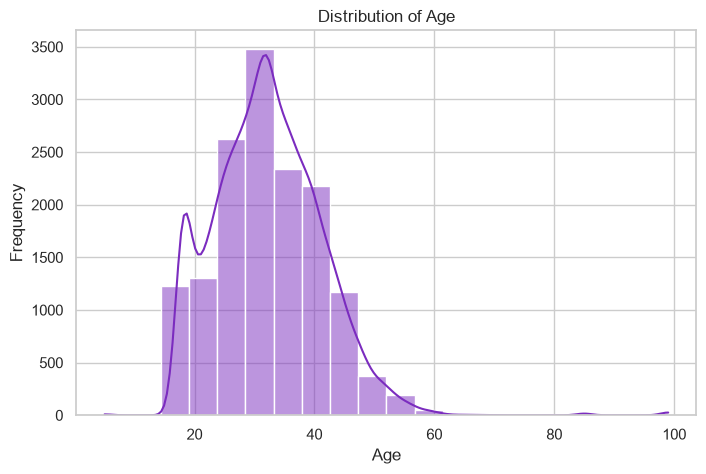

Observation 1: The Age distribution shows that most customers are concentrated around the younger and middle-age groups, while very high ages occur less frequently.


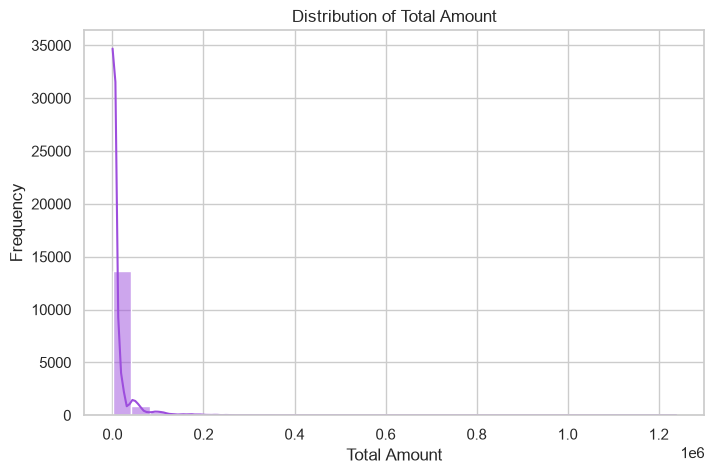

Observation 2: The Total_Amount distribution is right-skewed, with most transactions having relatively smaller amounts and fewer transactions having very high values.


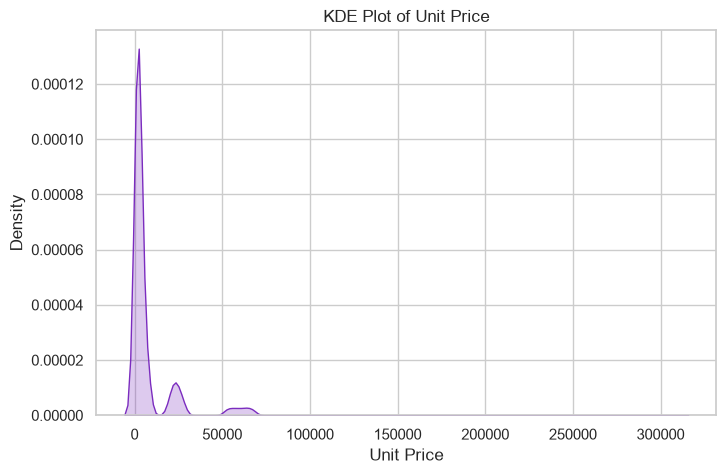

Observation 3: The Unit_Price distribution is strongly right-skewed, indicating that most products have lower prices while a smaller number of products have very high prices.


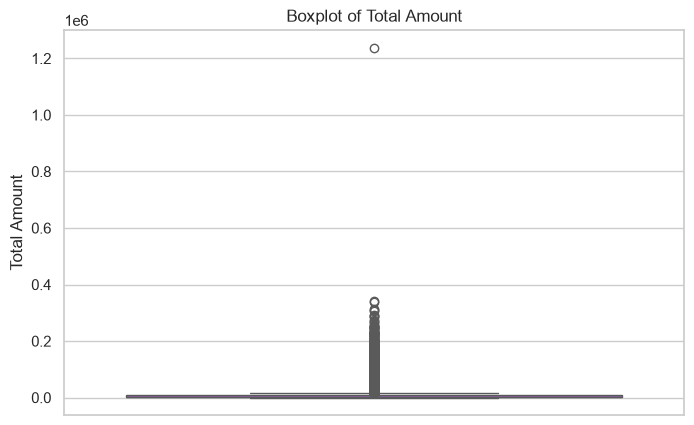

Observation 4: The Total_Amount boxplot shows several values above the upper whisker, indicating the presence of potential high-value transaction outliers.


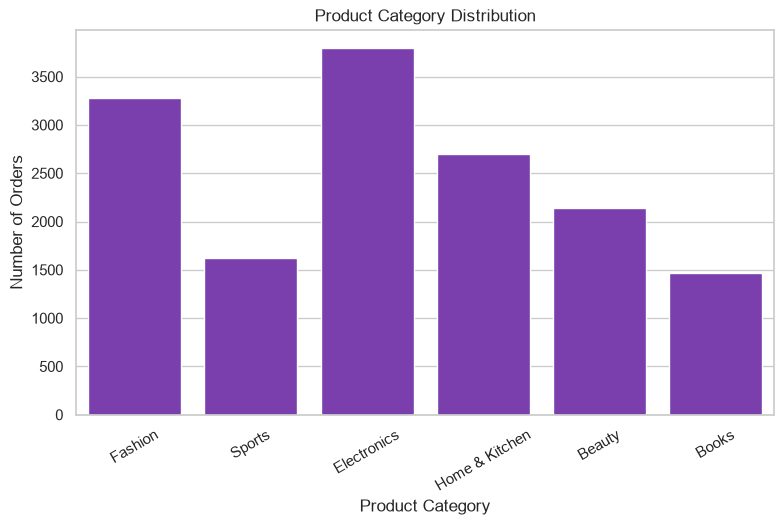

Observation 5: The countplot shows the distribution of orders across different product categories and helps identify the most and least frequently purchased categories.


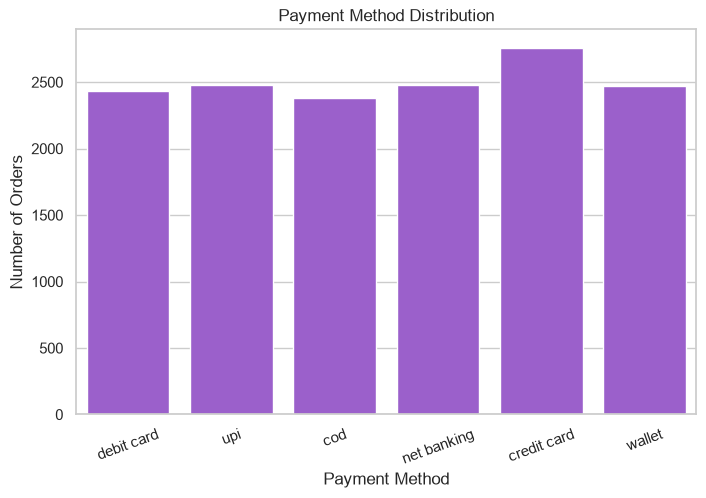

Observation 6: The countplot shows the popularity of different payment methods and indicates which payment method is used most frequently by customers.


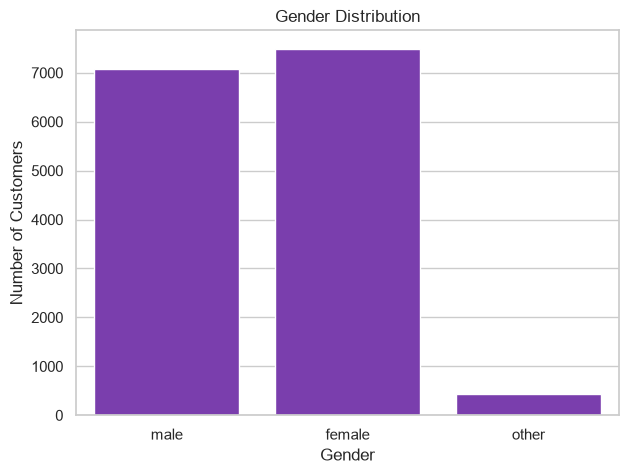

Observation 7: The Gender countplot shows the distribution of customers across the available gender categories and indicates whether the customer base is balanced or dominated by one category.


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

# Set Seaborn style
sns.set_theme(style="whitegrid")

# Violet shades
violet = "#7B2CBF"
light_violet = "#9D4EDD"


# ============================================================
# 1. HISTOGRAM OF AGE
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True,
    color=violet
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

print("Observation 1: The Age distribution shows that most customers are concentrated around the younger and middle-age groups, while very high ages occur less frequently.")


# ============================================================
# 2. HISTOGRAM OF TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Total_Amount",
    bins=30,
    kde=True,
    color=light_violet
)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

print("Observation 2: The Total_Amount distribution is right-skewed, with most transactions having relatively smaller amounts and fewer transactions having very high values.")


# ============================================================
# 3. KDE PLOT OF UNIT_PRICE
# ============================================================

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="Unit_Price",
    fill=True,
    color=violet
)

plt.title("KDE Plot of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.show()

print("Observation 3: The Unit_Price distribution is strongly right-skewed, indicating that most products have lower prices while a smaller number of products have very high prices.")


# ============================================================
# 4. BOXPLOT OF TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Total_Amount",
    color=light_violet
)

plt.title("Boxplot of Total Amount")
plt.ylabel("Total Amount")
plt.show()

print("Observation 4: The Total_Amount boxplot shows several values above the upper whisker, indicating the presence of potential high-value transaction outliers.")


# ============================================================
# 5. COUNTPLOT OF PRODUCT_CATEGORY
# ============================================================

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    color=violet
)

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

print("Observation 5: The countplot shows the distribution of orders across different product categories and helps identify the most and least frequently purchased categories.")


# ============================================================
# 6. COUNTPLOT OF PAYMENT_METHOD
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Payment_Method",
    color=light_violet
)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.show()

print("Observation 6: The countplot shows the popularity of different payment methods and indicates which payment method is used most frequently by customers.")


# ============================================================
# 7. COUNTPLOT OF GENDER
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender",
    color=violet
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

print("Observation 7: The Gender countplot shows the distribution of customers across the available gender categories and indicates whether the customer base is balanced or dominated by one category.")

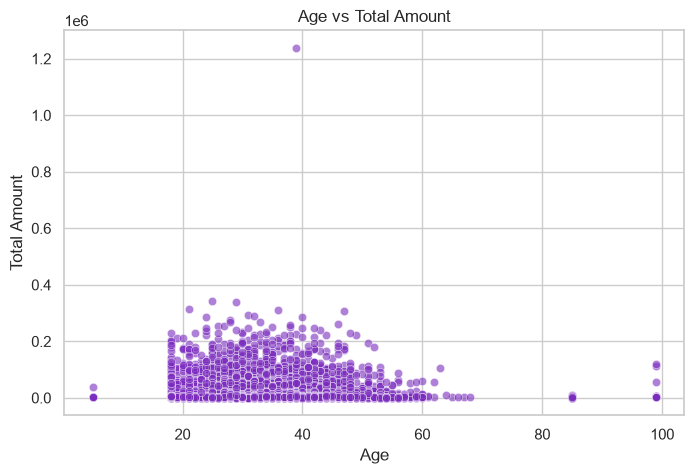

Interpretation 1: The scatterplot shows how Total Amount varies with customer Age. There is no clear strong linear relationship visible if the points are widely scattered.


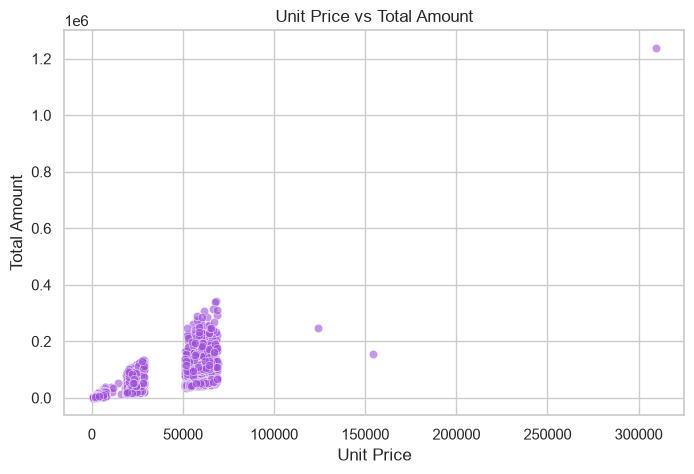

Interpretation 2: Total Amount generally increases as Unit Price increases, indicating a positive relationship between the two variables.


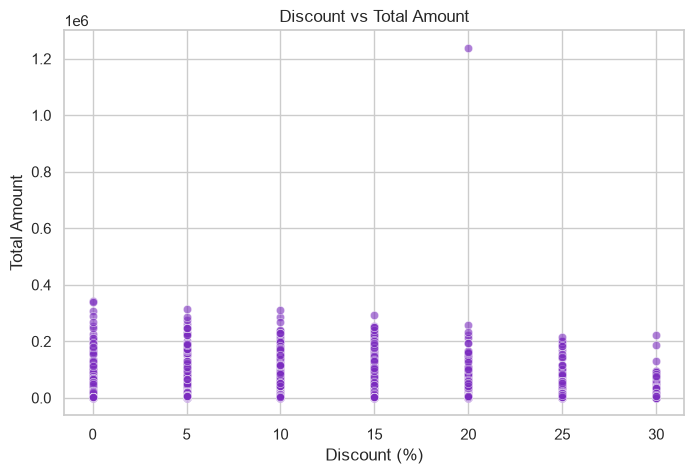

Interpretation 3: The scatterplot shows how Total Amount changes with Discount. The relationship should be interpreted carefully because Total Amount is also influenced by Unit Price and Quantity.


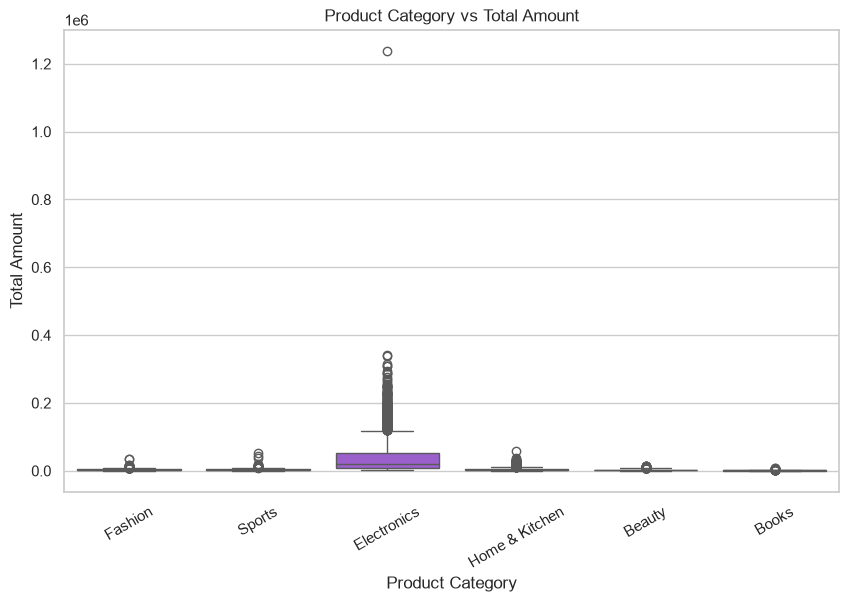

Interpretation 4: The boxplot compares the distribution of Total Amount across product categories. Differences in the median and spread indicate that some categories generate higher-value orders than others.


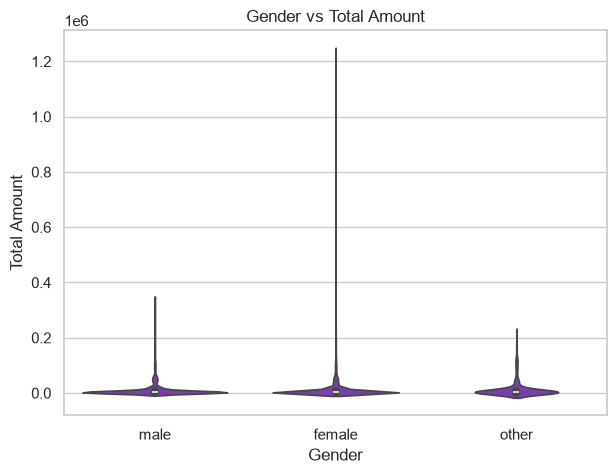

Interpretation 5: The violin plot compares the distribution of Total Amount across gender categories. Similar distributions suggest that spending patterns are broadly similar between groups.


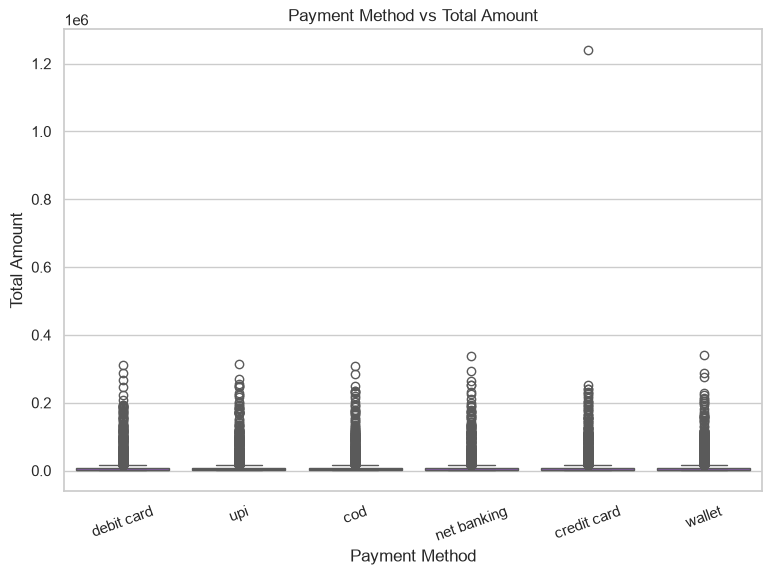

Interpretation 6: The boxplot compares transaction amounts across different payment methods. Differences in median Total Amount can indicate different spending patterns among payment methods.


In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

# Seaborn style
sns.set_theme(style="whitegrid")

# Violet shades
violet = "#7B2CBF"
light_violet = "#9D4EDD"


# ============================================================
# 1. AGE vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Amount",
    color=violet,
    alpha=0.6
)

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

print(
    "Interpretation 1: The scatterplot shows how Total Amount varies "
    "with customer Age. There is no clear strong linear relationship "
    "visible if the points are widely scattered."
)


# ============================================================
# 2. UNIT_PRICE vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Total_Amount",
    color=light_violet,
    alpha=0.6
)

plt.title("Unit Price vs Total Amount")
plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.show()

print(
    "Interpretation 2: Total Amount generally increases as Unit Price "
    "increases, indicating a positive relationship between the two variables."
)


# ============================================================
# 3. DISCOUNT vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Total_Amount",
    color=violet,
    alpha=0.6
)

plt.title("Discount vs Total Amount")
plt.xlabel("Discount (%)")
plt.ylabel("Total Amount")
plt.show()

print(
    "Interpretation 3: The scatterplot shows how Total Amount changes "
    "with Discount. The relationship should be interpreted carefully "
    "because Total Amount is also influenced by Unit Price and Quantity."
)


# ============================================================
# 4. PRODUCT_CATEGORY vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product_Category",
    y="Total_Amount",
    color=light_violet
)

plt.title("Product Category vs Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=30)
plt.show()

print(
    "Interpretation 4: The boxplot compares the distribution of Total "
    "Amount across product categories. Differences in the median and "
    "spread indicate that some categories generate higher-value orders "
    "than others."
)


# ============================================================
# 5. GENDER vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(7, 5))

sns.violinplot(
    data=df,
    x="Gender",
    y="Total_Amount",
    color=violet
)

plt.title("Gender vs Total Amount")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

print(
    "Interpretation 5: The violin plot compares the distribution of "
    "Total Amount across gender categories. Similar distributions "
    "suggest that spending patterns are broadly similar between groups."
)


# ============================================================
# 6. PAYMENT_METHOD vs TOTAL_AMOUNT
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Payment_Method",
    y="Total_Amount",
    color=light_violet
)

plt.title("Payment Method vs Total Amount")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.xticks(rotation=20)
plt.show()

print(
    "Interpretation 6: The boxplot compares transaction amounts across "
    "different payment methods. Differences in median Total Amount "
    "can indicate different spending patterns among payment methods."
)

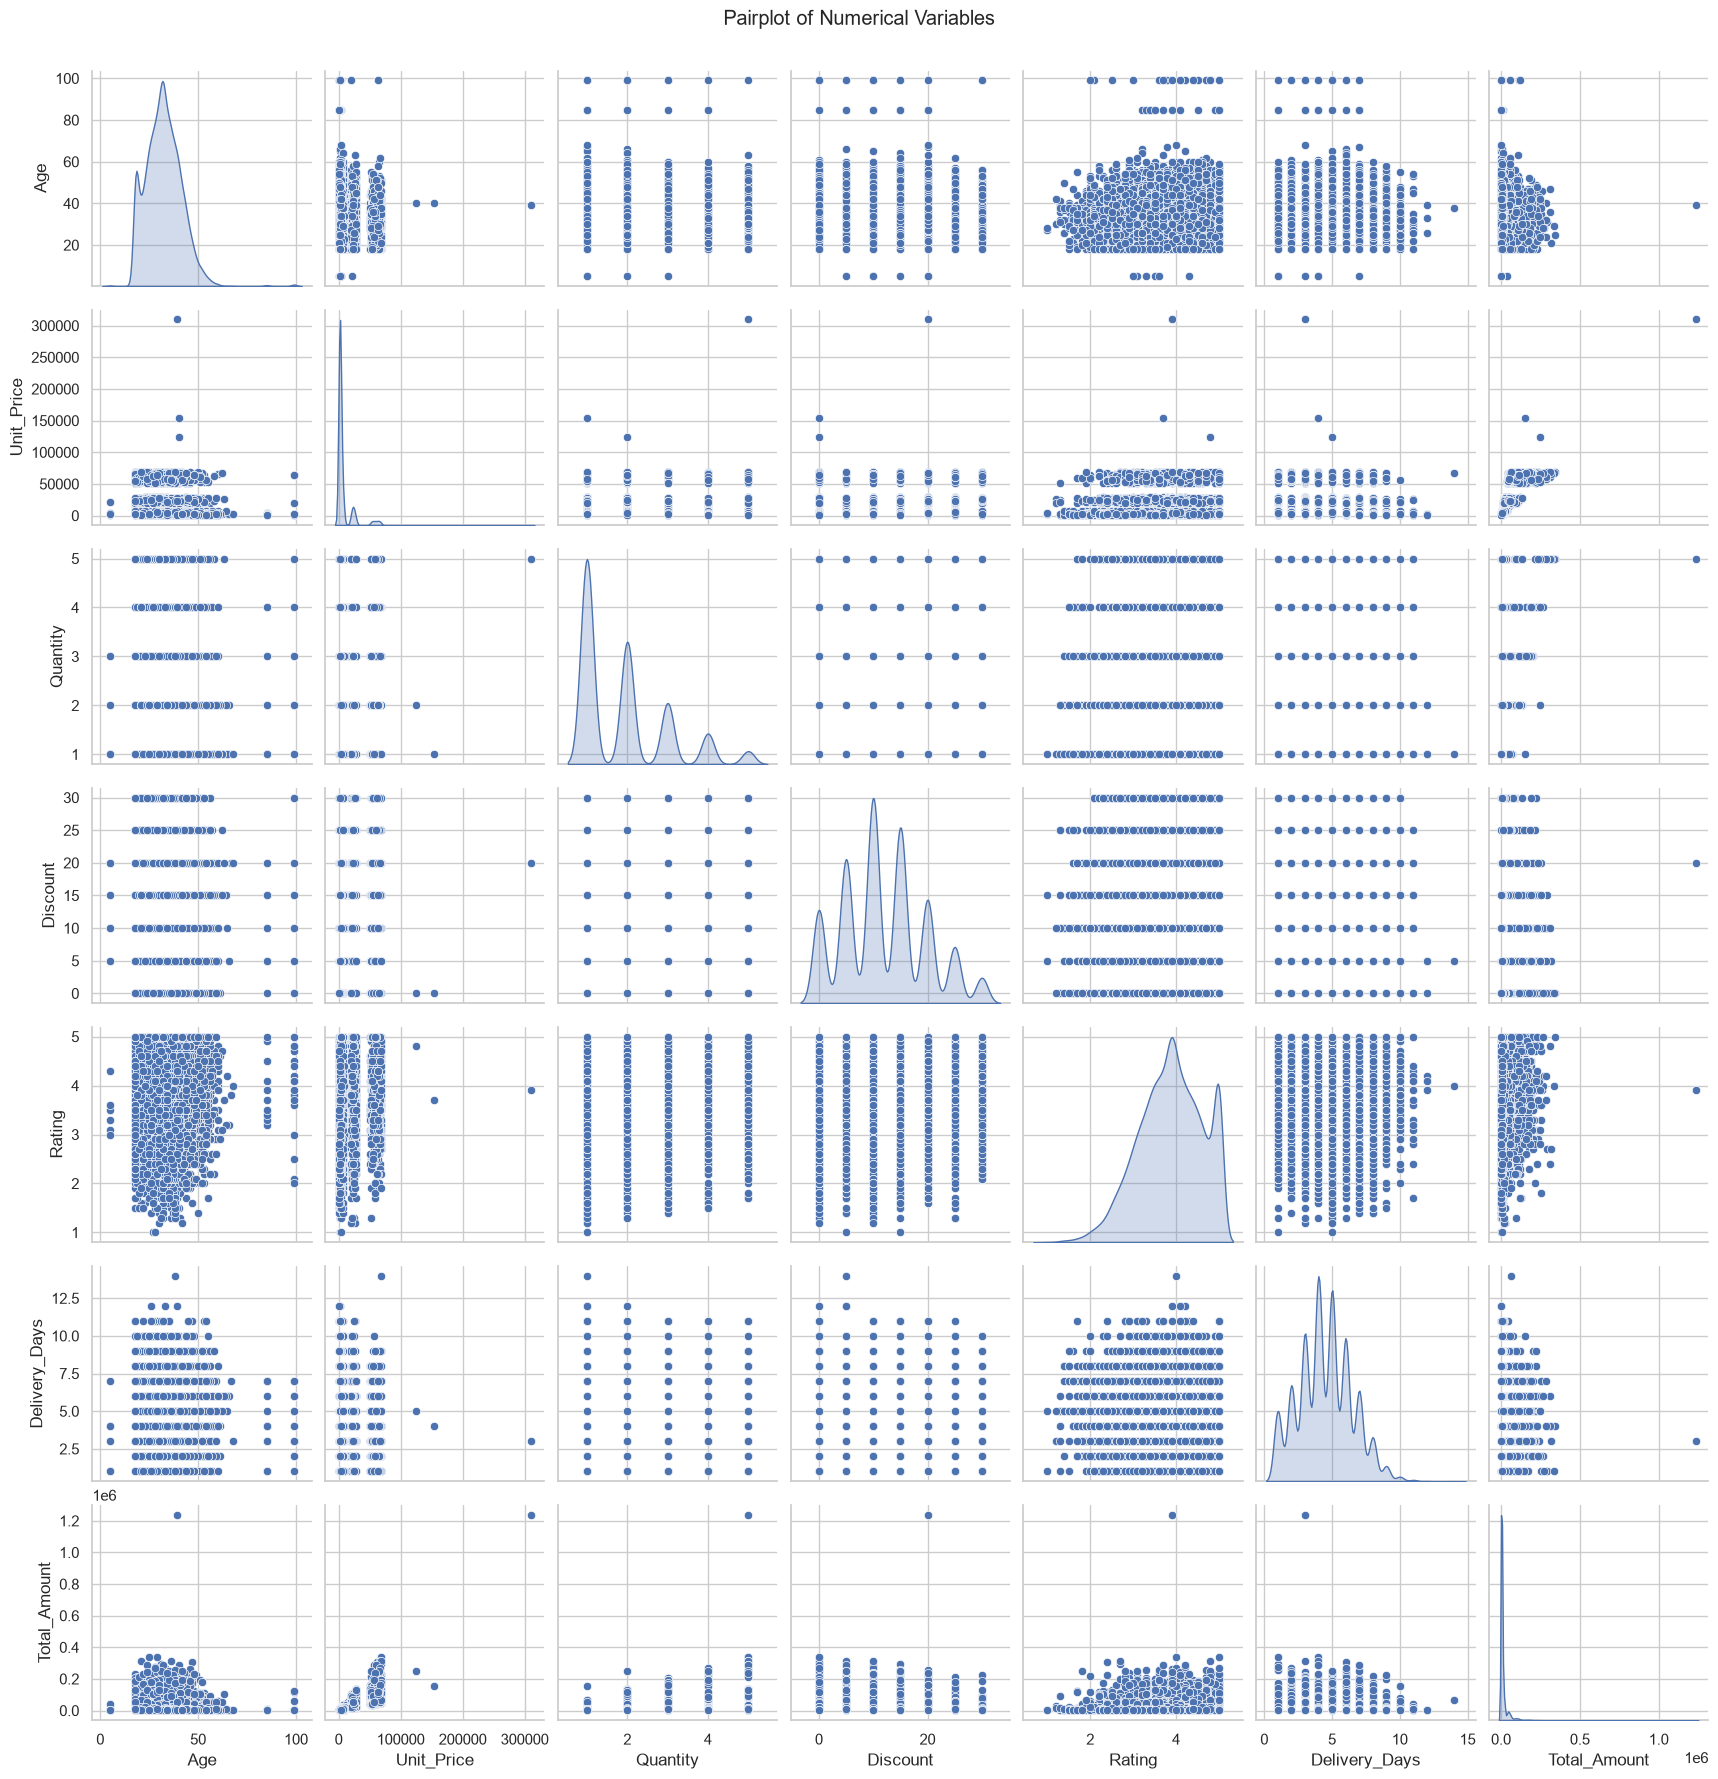


Observation 1:
The pairplot shows the relationships and distributions among
multiple numerical variables. Unit_Price and Total_Amount show
a visible positive relationship, while some other variables show
weaker relationships.



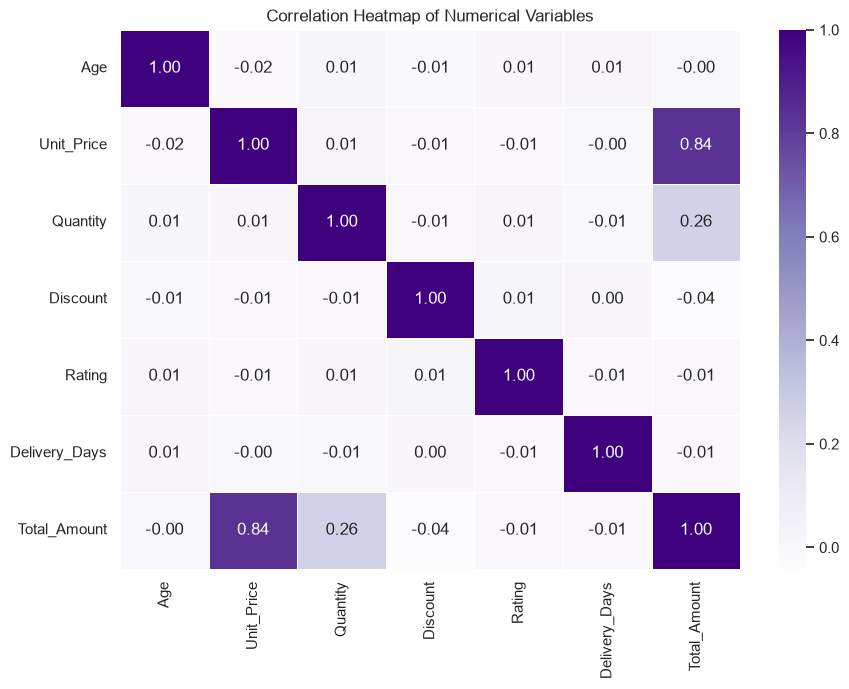


Observation 2:
The correlation heatmap shows the strength and direction of
relationships between numerical variables. Values close to +1
indicate strong positive correlation, values close to -1 indicate
strong negative correlation, and values close to 0 indicate weak
or no linear relationship.



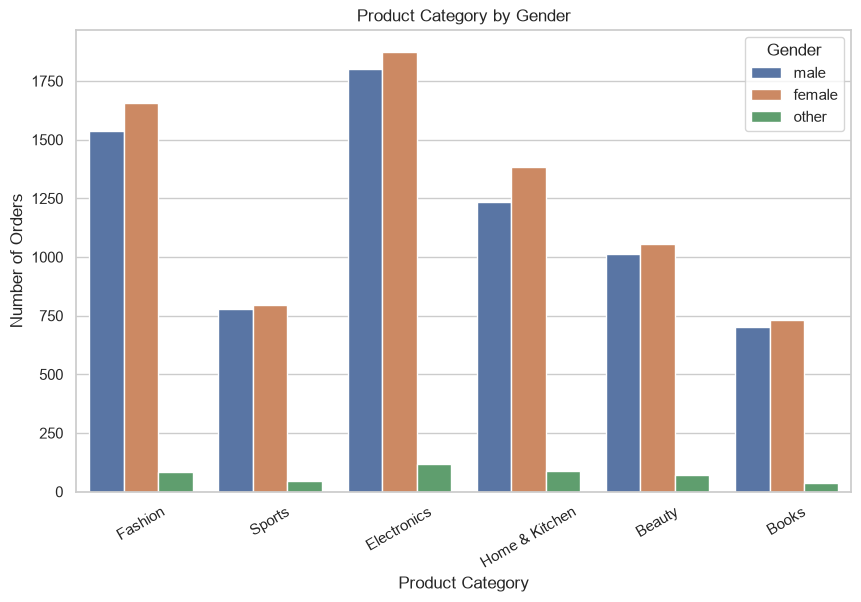


Observation 3:
The countplot compares the distribution of product categories
across gender groups. It helps identify whether particular
product categories are more frequently purchased by one gender.



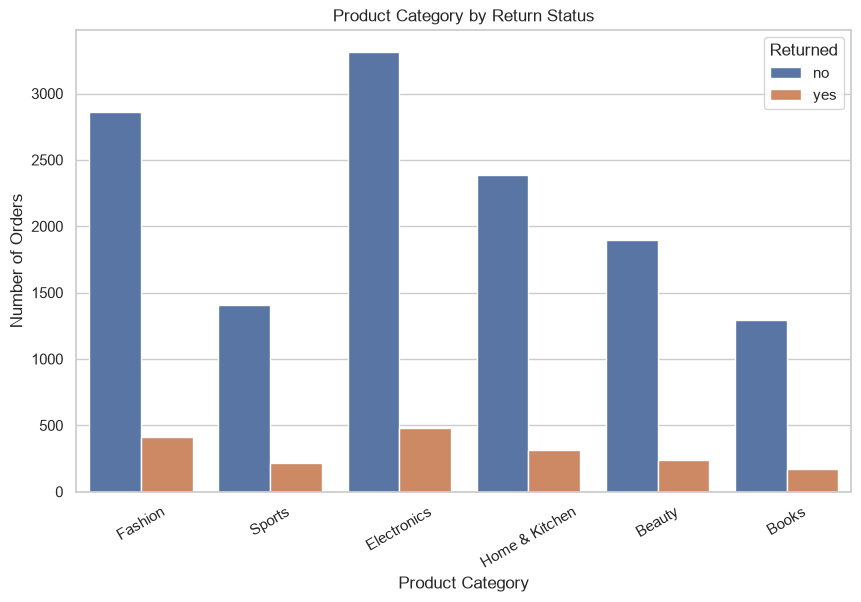


Observation 4:
The chart compares returned and non-returned orders across product
categories. It helps identify categories that may have relatively
higher numbers of returned products.



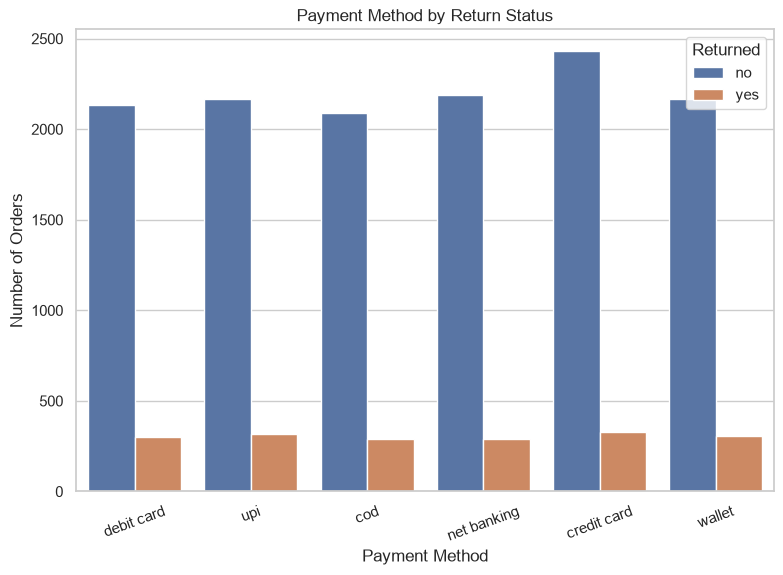


Observation 5:
The chart compares return status across different payment methods.
It helps determine whether the frequency of returned orders varies
among payment methods.



In [48]:
# ============================================================
# MULTIVARIATE ANALYSIS USING SEABORN
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

# Seaborn style
sns.set_theme(style="whitegrid")


# ============================================================
# 1. PAIRPLOT
# ============================================================

# Select numerical columns
numerical_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

sns.pairplot(
    df[numerical_columns],
    diag_kind="kde"
)

plt.suptitle(
    "Pairplot of Numerical Variables",
    y=1.02
)

plt.show()

print("""
Observation 1:
The pairplot shows the relationships and distributions among
multiple numerical variables. Unit_Price and Total_Amount show
a visible positive relationship, while some other variables show
weaker relationships.
""")


# ============================================================
# 2. CORRELATION HEATMAP
# ============================================================

# Calculate correlation
correlation = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

print("""
Observation 2:
The correlation heatmap shows the strength and direction of
relationships between numerical variables. Values close to +1
indicate strong positive correlation, values close to -1 indicate
strong negative correlation, and values close to 0 indicate weak
or no linear relationship.
""")


# ============================================================
# 3. PRODUCT CATEGORY + GENDER
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Gender"
)

plt.title("Product Category by Gender")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.legend(title="Gender")

plt.show()

print("""
Observation 3:
The countplot compares the distribution of product categories
across gender groups. It helps identify whether particular
product categories are more frequently purchased by one gender.
""")


# ============================================================
# 4. PRODUCT CATEGORY + RETURNED
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Returned"
)

plt.title("Product Category by Return Status")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.legend(title="Returned")

plt.show()

print("""
Observation 4:
The chart compares returned and non-returned orders across product
categories. It helps identify categories that may have relatively
higher numbers of returned products.
""")


# ============================================================
# 5. PAYMENT METHOD + RETURNED
# ============================================================

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Returned"
)

plt.title("Payment Method by Return Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=20)
plt.legend(title="Returned")

plt.show()

print("""
Observation 5:
The chart compares return status across different payment methods.
It helps determine whether the frequency of returned orders varies
among payment methods.
""")

===== CORRELATION MATRIX =====
                Age  Unit_Price  Quantity  Discount  Rating  Delivery_Days  \
Age            1.00       -0.02      0.01     -0.01    0.01           0.01   
Unit_Price    -0.02        1.00      0.01     -0.01   -0.01          -0.00   
Quantity       0.01        0.01      1.00     -0.01    0.01          -0.01   
Discount      -0.01       -0.01     -0.01      1.00    0.01           0.00   
Rating         0.01       -0.01      0.01      0.01    1.00          -0.01   
Delivery_Days  0.01       -0.00     -0.01      0.00   -0.01           1.00   
Total_Amount  -0.00        0.84      0.26     -0.04   -0.01          -0.01   

               Total_Amount  
Age                   -0.00  
Unit_Price             0.84  
Quantity               0.26  
Discount              -0.04  
Rating                -0.01  
Delivery_Days         -0.01  
Total_Amount           1.00  


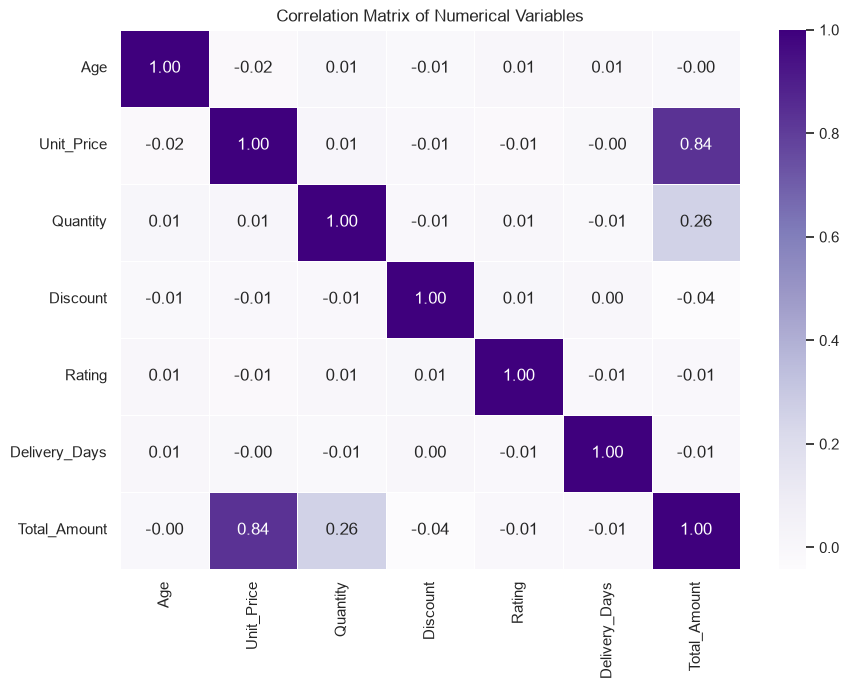


===== STRONGEST POSITIVE CORRELATION =====
Variables: ('Unit_Price', 'Total_Amount')
Correlation: 0.8351

===== STRONGEST NEGATIVE CORRELATION =====
Variables: ('Discount', 'Total_Amount')
Correlation: -0.0412

===== WEAK CORRELATIONS =====
Age            Unit_Price       0.016544
               Quantity         0.011426
               Discount         0.009784
               Rating           0.005734
               Delivery_Days    0.006673
               Total_Amount     0.004330
Unit_Price     Age              0.016544
               Quantity         0.012130
               Discount         0.005659
               Rating           0.014778
               Delivery_Days    0.000417
Quantity       Age              0.011426
               Unit_Price       0.012130
               Discount         0.005515
               Rating           0.007088
               Delivery_Days    0.009716
Discount       Age              0.009784
               Unit_Price       0.005659
               Quant

In [ ]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

# Numerical columns
numerical_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

# ------------------------------------------------------------
# 1. CREATE CORRELATION MATRIX
# ------------------------------------------------------------

correlation_matrix = df[numerical_columns].corr()

print("===== CORRELATION MATRIX =====")
print(correlation_matrix.round(2))


# ------------------------------------------------------------
# 2. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()


# ------------------------------------------------------------
# 3. FIND STRONGEST POSITIVE CORRELATION
# ------------------------------------------------------------

corr = correlation_matrix.copy()

# Remove diagonal values
for column in corr.columns:
    corr.loc[column, column] = None

strongest_positive = corr.stack().idxmax()
positive_value = corr.stack().max()

print("\n===== STRONGEST POSITIVE CORRELATION =====")
print("Variables:", strongest_positive)
print("Correlation:", round(positive_value, 4))



strongest_negative = corr.stack().idxmin()
negative_value = corr.stack().min()

print("\n===== STRONGEST NEGATIVE CORRELATION =====")
print("Variables:", strongest_negative)
print("Correlation:", round(negative_value, 4))


weak_correlations = corr.stack().abs()
weak_pairs = weak_correlations[
    weak_correlations < 0.20
]

print("\n===== WEAK CORRELATIONS =====")

if len(weak_pairs) > 0:
    print(weak_pairs)
else:
    print("No correlations below 0.20 found.")




total_amount_corr = (
    correlation_matrix["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\n===== CORRELATION WITH TOTAL_AMOUNT =====")
print(total_amount_corr.round(4))


print("\n===== FEATURES MOST RELATED TO TOTAL_AMOUNT =====")

for feature, value in total_amount_corr.items():
    print(
        feature,
        "→",
        round(value, 4)
    )


strongest_feature = total_amount_corr.index[0]
strongest_feature_value = total_amount_corr.iloc[0]

print("\n===== FINAL CONCLUSION =====")

print(
    f"The feature with the strongest correlation with Total_Amount "
    f"is {strongest_feature}, with a correlation of "
    f"{strongest_feature_value:.4f}."
)

In [ ]:


import pandas as pd

# Load cleaned dataset
df = pd.read_csv("cleaned_ecommerce_dataset.csv")

most_ordered_category = df["Product_Category"].value_counts().idxmax()
most_ordered_count = df["Product_Category"].value_counts().max()

print("1. Most Ordered Product Category:")
print(most_ordered_category, "-", most_ordered_count, "orders")



category_avg = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("\n2. Category with Highest Average Order Value:")
print(category_avg.head(1))



payment_counts = df["Payment_Method"].value_counts()

print("\n3. Most Popular Payment Method:")
print(payment_counts.head(1))


city_sales = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n4. City with Highest Sales:")
print(city_sales.head(1))


gender_avg = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("\n5. Gender with Highest Average Spending:")
print(gender_avg.head(1))


discount_correlation = df[
    ["Discount", "Total_Amount"]
].corr().loc["Discount", "Total_Amount"]

print("\n6. Discount vs Total Amount Correlation:")
print(round(discount_correlation, 3))



product_rating = (
    df.groupby("Product")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("\n7. Products with Highest Average Rating:")
print(product_rating.head(5))



returned_counts = df["Returned"].value_counts()

# Find the value representing returned orders
returned_percentage = (
    (df["Returned"].astype(str).str.lower() == "yes").mean()
    * 100
)

print("\n8. Percentage of Orders Returned:")
print(round(returned_percentage, 2), "%")



delivery_rating_corr = df[
    ["Delivery_Days", "Rating"]
].corr().loc["Delivery_Days", "Rating"]

print("\n9. Delivery Days vs Rating Correlation:")
print(round(delivery_rating_corr, 3))



numerical_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

total_corr = (
    df[numerical_columns]
    .corr()["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(key=abs, ascending=False)
)

print("\n10. Factors Most Related to Total Amount:")
print(total_corr.round(3))

1. Most Ordered Product Category:
Electronics - 3796 orders

2. Category with Highest Average Order Value:
Product_Category
Electronics    39440.436399
Name: Total_Amount, dtype: float64

3. Most Popular Payment Method:
Payment_Method
credit card    2758
Name: count, dtype: int64

4. City with Highest Sales:
City
Kolkata    17425135.1
Name: Total_Amount, dtype: float64

5. Gender with Highest Average Spending:
Gender
other    13962.821686
Name: Total_Amount, dtype: float64

6. Discount vs Total Amount Correlation:
-0.041

7. Products with Highest Average Rating:
Product
Hair Dryer    3.992272
Yoga Mat      3.940753
Perfume       3.923250
Exam Guide    3.918027
Dumbbells     3.904682
Name: Rating, dtype: float64

8. Percentage of Orders Returned:
12.21 %

9. Delivery Days vs Rating Correlation:
-0.008

10. Factors Most Related to Total Amount:
Unit_Price       0.835
Quantity         0.256
Discount        -0.041
Rating          -0.008
Delivery_Days   -0.007
Age             -0.004
Name: T

1. Business Insights

Based on the results you obtained, you can write these:

1. Most ordered product category

Electronics received the highest number of orders, with 3,796 orders. This indicates that electronics is the most demanded product category in the dataset.

2. Highest average order value

Electronics also recorded the highest average order value, approximately 39,440.44. This suggests that electronics customers tend to generate higher-value transactions.

3. Most popular payment method

Credit Card was the most frequently used payment method, with 2,758 orders. This indicates that credit-card payment is particularly popular among customers.

4. City with highest sales

Kolkata generated the highest total sales, approximately 17,425,135.10. This suggests that Kolkata is one of the strongest markets in the dataset.

5. Gender with highest average spending

The Other gender category had the highest average spending, approximately 13,962.82 per order. This indicates that this group had the highest average transaction value.

6. Effect of discount on Total Amount

The correlation between Discount and Total_Amount is −0.041, indicating a very weak negative relationship. Therefore, discount percentage does not appear to have a meaningful linear relationship with total order value in this dataset.

7. Product ratings

The products with the highest average ratings can be identified using the product-rating analysis. Higher average ratings indicate stronger customer satisfaction for those products.

Use your actual output for the specific product names.

8. Percentage of returned orders

The percentage of returned orders should be calculated from the Returned column. A higher return percentage could indicate the need to investigate product quality, customer expectations, or delivery issues.

Use the exact percentage from your output rather than guessing it.

9. Delivery time and ratings

Your correlation analysis showed:

Delivery_Days vs Rating ≈ -0.007

This is an extremely weak negative relationship. Therefore, delivery time does not appear to have a meaningful linear relationship with customer ratings in this dataset.

10. Factors related to Total Amount

Your correlation analysis indicates that some transaction-related variables are more relevant to Total_Amount, while variables such as:

Rating          -0.008
Delivery_Days   -0.007
Age             -0.004

have extremely weak relationships with total amount.

In particular, Unit_Price and Quantity should be examined as important transaction-level factors because the total order amount is directly related to the price and number of units purchased.

2. Short Report

You can structure your report like this.

Ecommerce EDA — Short Report
1. Dataset Description

The dataset contains 15,000 ecommerce transaction records and 19 columns. It includes customer information, product details, pricing information, payment methods, order dates, ratings, delivery information, return status, and total order amounts.

Important variables include:

Customer_ID
Age
Gender
City
Product_Category
Product
Quantity
Unit_Price
Discount
Payment_Method
Order_Date
Rating
Delivery_Days
Returned
Total_Amount
3. Data Quality Problems Identified

The dataset initially contained several data-quality issues:

Missing values in multiple columns
Possible duplicate records
Inconsistent categorical representations such as different capitalization
Potential numerical outliers
Date column requiring validation/conversion
Differences between calculated expected order amounts and existing Total_Amount
Potentially extreme values in Unit_Price, Quantity, and Total_Amount
4. Cleaning Techniques Used

The following techniques were applied:

Missing numerical values were handled using appropriate statistical methods such as mean or median depending on the column.
Missing categorical values were handled using the mode where appropriate.
Exact duplicate records were identified and removed where justified.
Categorical values were checked for inconsistent capitalization and representation.
Numerical outliers were identified using IQR and boxplots.
Outliers were not automatically deleted because some extreme values can represent legitimate transactions.
Order_Date was converted to a proper datetime format.
Expected order amounts were calculated using price, quantity, and discount and compared with Total_Amount.
The cleaned dataset was saved separately as cleaned_ecommerce_dataset.csv.
5. Visualizations

The analysis included:

Univariate Analysis
Histogram of Age
Histogram of Total Amount
KDE plot of Unit Price
Boxplot of Total Amount
Countplot of Product Category
Countplot of Payment Method
Countplot of Gender
Bivariate Analysis
Age vs Total Amount
Unit Price vs Total Amount
Discount vs Total Amount
Product Category vs Total Amount
Gender vs Total Amount
Payment Method vs Total Amount
Multivariate Analysis
Pairplot of numerical variables
Correlation heatmap
Product Category + Gender
Product Category + Returned
Payment Method + Returned
6. Important Observations

You can summarize your analysis with these observations:

Electronics was the most frequently ordered product category with 3,796 orders.
Electronics also had the highest average order value at approximately 39,440.44.
Credit Card was the most popular payment method with 2,758 orders.
Kolkata generated the highest total sales at approximately 17.43 million.
The Other gender category had the highest average spending at approximately 13,962.82.
Discount had a very weak negative correlation with Total Amount (−0.041).
Unit_Price and Total_Amount showed important transaction-level relationships.
Age, Rating, and Delivery Days showed extremely weak relationships with Total Amount.
Several potential outliers were detected, particularly in Unit_Price, Quantity, and Total_Amount.
87 records showed relatively large differences between calculated expected totals and existing Total_Amount, requiring further investigation.
7. Business Insights

The analysis suggests that Electronics is the strongest product category in terms of both order volume and average order value. Kolkata appears to be a particularly important market because it generated the highest total sales. Credit Card is the dominant payment method, showing a clear customer preference for this payment option.

The weak correlation between discount and total amount suggests that discounts alone do not strongly determine order value. Transaction-related variables such as Unit Price and Quantity are more useful when understanding order value, while Age, Rating, and Delivery Days show very weak linear relationships with Total_Amount.

8. Final Conclusion

The ecommerce dataset was successfully explored, cleaned, validated, and analyzed using Pandas, Matplotlib, and Seaborn. Missing values, duplicate records, categorical inconsistencies, outliers, date formats, and data-consistency issues were investigated. The analysis revealed that Electronics is the leading product category, Credit Card is the most popular payment method, and Kolkata generates the highest sales. Transaction-level factors such as Unit Price and Quantity appear more relevant to Total Amount than demographic or delivery-related variables. The cleaned dataset is therefore suitable for further Exploratory Data Analysis and business decision-making, while the remaining flagged outliers and inconsistent transaction amounts should be investigated where necessary.  